# Aoranema — Advanced Personalized Movie Recommendation V2 (Final Audit)

Notebook ini adalah **versi final-audit** dari eksperimen Personalized Movie Recommendation V2.

Versi sebelumnya berhasil menunjukkan bahwa metadata-enhanced XGBRanker jauh lebih kuat daripada genre-only ranker. Namun sebelum model dikunci untuk production, notebook ini melakukan audit terakhir terhadap dua sumber optimisme/leakage yang perlu diperbaiki.

## Perbaikan audit

### 1. Future-interaction leakage pada negative sampling diperbaiki
Pada versi sebelumnya, sampled negative diambil dari film yang **tidak pernah** dirating user pada seluruh timeline. Itu berarti film yang baru akan dirating user di masa depan ikut dikeluarkan dari negative pool.

Versi ini hanya mengecualikan film yang sudah diketahui user **sampai snapshot recommendation saat itu**.

```text
sebelumnya:
exclude = semua film yang pernah dirating user
          termasuk future interactions

sekarang:
exclude = film yang sudah dirating sampai snapshot
          future interactions tetap dianggap unseen
```

### 2. Historical movie popularity/rating diaudit
Feature:

- `movie_historical_rating_norm`
- `movie_historical_log_count_norm`

pada V2 awal dibangun dari stage history seluruh user. Karena cutoff setiap user berbeda secara waktu kalender, statistik tersebut berpotensi melihat interaksi user lain yang berada setelah snapshot user target.

Karena itu:
- model advanced lama tetap dilatih sebagai **audit reference**,
- tetapi **tidak eligible menjadi final model**,
- final model hanya dipilih dari varian yang membuang dua feature tersebut.

### 3. Ablation test
Tiga varian leakage-safe dibandingkan:

1. `leakage_safe_full_content`
   - membuang historical movie rating/count saja.

2. `leakage_safe_no_metadata_counts`
   - juga membuang jumlah director/writer/cast/keyword sebagai proxy dokumentasi/popularitas.

3. `personalization_content_core`
   - lebih ketat: fokus pada preference, affinity, genre, tahun, umur film, runtime, bahasa, dan franchise.

Final model dipilih **hanya berdasarkan Validation NDCG@10** sebelum melihat final test.

---

## Data

### MovieLens 32M
- histori rating
- timestamp
- genre
- user preference

### Aoranema TMDB Metadata
- director
- writer
- top cast
- keyword
- production company
- collection/franchise
- release year
- runtime
- original language

## Final evaluation

- Precision@10
- Recall@10
- NDCG@10
- HitRate@10
- MAP@10

> NDCG@10 bukan "akurasi". Evaluasi dilakukan pada sampled candidate ranking set.

## Sebelum Run All di Kaggle

Tambahkan dua private dataset:

- `aoranema-movielens-32m`
- `aoranema-tmdb-metadata`

Gunakan:

```text
Accelerator : GPU T4
Internet    : tidak diperlukan
```

Default:

```python
RUN_MODE = "full"
```

Jika hanya ingin mengecek pipeline lebih cepat:

```python
RUN_MODE = "debug"
```

Setelah debug berhasil, ubah kembali ke `full` dan **Run All dari awal**.

Notebook ini memang melakukan beberapa training tambahan karena audit membutuhkan ablation model. Semua varian menggunakan candidate set dan validation protocol yang sama.

In [1]:
# ============================================================
# 0. SETUP & CONFIGURATION
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import json
import math
import os
import random
import re
import shutil
import subprocess
import time
import warnings
import zlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize as sk_normalize

import xgboost as xgb
from packaging import version

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# ------------------------------------------------------------
# Run mode
# ------------------------------------------------------------
RUN_MODE = "full"  # "full" atau "debug"
DEBUG_N_ROWS = 2_000_000

# ------------------------------------------------------------
# User chronological split
# ------------------------------------------------------------
MIN_USER_RATINGS = 20

PROFILE_FRAC = 0.50
TRAIN_END_FRAC = 0.70
VAL_END_FRAC = 0.85
# 0-50% profile history
# 50-70% ranking train target
# 70-85% validation target
# 85-100% test target

# ------------------------------------------------------------
# Candidate sampling
# ------------------------------------------------------------
MAX_TRAIN_USERS_FULL = 120_000
MAX_EVAL_USERS_FULL = 20_000

MAX_TRAIN_USERS_DEBUG = 5_000
MAX_EVAL_USERS_DEBUG = 1_000

MAX_TRAIN_OBSERVED_PER_USER = 6
TRAIN_NEGATIVES_PER_USER = 12

MAX_EVAL_OBSERVED_PER_USER = 5
EVAL_NEGATIVES_PER_USER = 100

RELEVANT_RATING_THRESHOLD = 4.0

# ------------------------------------------------------------
# Preference smoothing
# ------------------------------------------------------------
GENRE_ALPHA = 5.0
MOVIE_ALPHA = 20.0

RATING_MIN = 0.5
RATING_MAX = 5.0
RATING_RANGE = RATING_MAX - RATING_MIN

# ------------------------------------------------------------
# Metadata hashing
# Hashing menjaga dimensi tetap kecil walaupun ada ribuan
# actor/director/writer/keyword.
# ------------------------------------------------------------
HASH_CONFIG = {
    "director":   {"column": "director_ids_json",            "dim": 64,  "salt": "director"},
    "writer":     {"column": "writer_ids_json",              "dim": 96,  "salt": "writer"},
    "cast":       {"column": "top_cast_ids_json",            "dim": 128, "salt": "cast"},
    "keyword":    {"column": "keyword_ids_json",             "dim": 256, "salt": "keyword"},
    "company":    {"column": "production_company_ids_json",  "dim": 64,  "salt": "company"},
    "collection": {"column": "collection_ids_json",          "dim": 32,  "salt": "collection"},
}

TOP_LANGUAGE_N = 12

# ------------------------------------------------------------
# XGBoost Ranker
# ------------------------------------------------------------
XGB_N_ESTIMATORS = 1200
XGB_LEARNING_RATE = 0.05
XGB_MAX_DEPTH = 6
XGB_MAX_BIN = 256
XGB_EARLY_STOPPING = 60

RANKING_K = 10

# ------------------------------------------------------------
# Memory / batch
# ------------------------------------------------------------
FEATURE_BATCH_SIZE = 250_000
AFFINITY_BATCH_SIZE = 200_000

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------
ARTIFACT_DIR = Path("/kaggle/working/aoranema_recommender_v2_final_audit")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)
print("XGBoost:", xgb.__version__)
print("Mode   :", RUN_MODE)

Pandas : 2.3.3
NumPy  : 2.0.2
XGBoost: 3.2.0
Mode   : full


In [2]:
# ============================================================
# 1. CHECK GPU
# ============================================================

def has_nvidia_gpu():
    try:
        result = subprocess.run(
            ["nvidia-smi"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            check=False,
        )
        print(result.stdout[:2500])
        return result.returncode == 0 and "NVIDIA" in result.stdout
    except Exception:
        return False

GPU_AVAILABLE = has_nvidia_gpu()
print("GPU detected:", GPU_AVAILABLE)

if not GPU_AVAILABLE:
    print(
        "\nWARNING: GPU tidak terdeteksi. "
        "Notebook tetap memiliki fallback CPU, "
        "tetapi full XGBRanker akan jauh lebih lambat."
    )

Sat Sep 19 13:11:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ============================================================
# 2. AUTO-DETECT BOTH KAGGLE DATASETS
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")
assert KAGGLE_INPUT.exists(), "Notebook harus dijalankan di Kaggle."

# MovieLens
ratings_candidates = list(KAGGLE_INPUT.rglob("ratings.csv"))

MOVIELENS_DIR = None
for p in ratings_candidates:
    parent = p.parent
    if (
        (parent / "movies.csv").exists()
        and (parent / "links.csv").exists()
    ):
        MOVIELENS_DIR = parent
        break

assert MOVIELENS_DIR is not None, (
    "MovieLens 32M tidak ditemukan. "
    "Tambahkan dataset aoranema-movielens-32m sebagai Input."
)

RATINGS_PATH = MOVIELENS_DIR / "ratings.csv"
MOVIES_PATH = MOVIELENS_DIR / "movies.csv"
LINKS_PATH = MOVIELENS_DIR / "links.csv"

# TMDB
tmdb_parquet_candidates = list(
    KAGGLE_INPUT.rglob("tmdb_metadata.parquet")
)

TMDB_PATH = None
if tmdb_parquet_candidates:
    preferred = [
        p for p in tmdb_parquet_candidates
        if "aoranema" in str(p).lower()
        and "tmdb" in str(p).lower()
    ]
    TMDB_PATH = preferred[0] if preferred else tmdb_parquet_candidates[0]

if TMDB_PATH is None:
    tmdb_csv_candidates = list(
        KAGGLE_INPUT.rglob("tmdb_metadata.csv")
    )
    if tmdb_csv_candidates:
        TMDB_PATH = tmdb_csv_candidates[0]

assert TMDB_PATH is not None, (
    "TMDB metadata tidak ditemukan. "
    "Tambahkan dataset aoranema-tmdb-metadata sebagai Input."
)

metadata_info_candidates = list(
    KAGGLE_INPUT.rglob("metadata_info.json")
)
METADATA_INFO_PATH = (
    metadata_info_candidates[0]
    if metadata_info_candidates
    else None
)

print("MovieLens dir :", MOVIELENS_DIR)
print("ratings.csv   :", RATINGS_PATH)
print("movies.csv    :", MOVIES_PATH)
print("links.csv     :", LINKS_PATH)
print("TMDB metadata :", TMDB_PATH)
print("Metadata info :", METADATA_INFO_PATH)

MovieLens dir : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m
ratings.csv   : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m/ratings.csv
movies.csv    : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m/movies.csv
links.csv     : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m/links.csv
TMDB metadata : /kaggle/input/datasets/onallaaldeanuva/aoranema-tmdb-metadata/tmdb_metadata.parquet
Metadata info : /kaggle/input/datasets/onallaaldeanuva/aoranema-tmdb-metadata/metadata_info.json


In [4]:
# ============================================================
# 3. LOAD MOVIES + LINKS + TMDB AND BUILD ENRICHED MOVIE TABLE
# ============================================================

movies = pd.read_csv(
    MOVIES_PATH,
    dtype={
        "movieId": "int32",
        "title": "string",
        "genres": "string",
    },
)

links = pd.read_csv(
    LINKS_PATH,
    dtype={
        "movieId": "int32",
        "imdbId": "Int64",
        "tmdbId": "Int64",
    },
)

if TMDB_PATH.suffix.lower() == ".parquet":
    tmdb = pd.read_parquet(TMDB_PATH)
else:
    tmdb = pd.read_csv(TMDB_PATH)

tmdb["tmdbId"] = pd.to_numeric(
    tmdb["tmdbId"],
    errors="coerce",
).astype("Int64")

# Satu tmdbId cukup satu metadata record.
tmdb_unique = (
    tmdb.sort_values("tmdbId")
    .drop_duplicates(subset=["tmdbId"], keep="last")
    .copy()
)

# Hindari konflik movieId MovieLens dari collector.
tmdb_for_merge = tmdb_unique.drop(
    columns=[
        "movieId",
        "imdbId",
        "movielens_title",
        "movielens_genres",
    ],
    errors="ignore",
)

movie_meta = (
    movies
    .merge(links, on="movieId", how="left")
    .merge(
        tmdb_for_merge,
        on="tmdbId",
        how="left",
        suffixes=("", "_tmdb"),
    )
)

assert len(movie_meta) == len(movies)
assert movie_meta["movieId"].is_unique

print("MovieLens movies:", f"{len(movies):,}")
print("TMDB raw rows   :", f"{len(tmdb):,}")
print(
    "Matched TMDB    :",
    f"{movie_meta['tmdb_title'].notna().sum():,}"
)

if METADATA_INFO_PATH is not None:
    with open(METADATA_INFO_PATH, "r", encoding="utf-8") as f:
        metadata_info = json.load(f)
    print("\nmetadata_info.json:")
    print(json.dumps(metadata_info, indent=2)[:3000])

display(
    movie_meta[
        [
            "movieId",
            "tmdbId",
            "title",
            "genres",
            "tmdb_title",
            "release_year",
            "runtime",
            "original_language",
        ]
    ].head()
)

MovieLens movies: 87,585
TMDB raw rows   : 86,214
Matched TMDB    : 86,249

metadata_info.json:
{
  "project": "Aoranema TMDB Metadata Enrichment",
  "source": "TMDB API",
  "movielens_total_movies": 87585,
  "movielens_valid_tmdb_ids": 87461,
  "metadata_rows_collected": 86214,
  "failed_requests": 1212,
  "coverage_pct_of_valid_tmdb_ids": 98.57422165307966,
  "top_cast_n": 5,
  "max_writers": 10,
  "language": "en-US",
  "fields": [
    "movieId",
    "tmdbId",
    "imdbId",
    "movielens_title",
    "movielens_genres",
    "tmdb_title",
    "original_title",
    "release_date",
    "release_year",
    "runtime",
    "original_language",
    "genre_ids_json",
    "genre_names_json",
    "director_ids_json",
    "director_names_json",
    "writer_ids_json",
    "writer_names_json",
    "top_cast_ids_json",
    "top_cast_names_json",
    "keyword_ids_json",
    "keyword_names_json",
    "production_company_ids_json",
    "production_company_names_json",
    "collection_id",
    "colle

,movieId,tmdbId,title,genres,tmdb_title,release_year,runtime,original_language
0,1,862,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Toy Story,1995.0,81.0,en
1,2,8844,Jumanji (1995),Adventure|Children|Fantasy,Jumanji,1995.0,104.0,en
2,3,15602,Grumpier Old Men (1995),Comedy|Romance,Grumpier Old Men,1995.0,101.0,en
3,4,31357,Waiting to Exhale (1995),Comedy|Drama|Romance,Waiting to Exhale,1995.0,127.0,en
4,5,11862,Father of the Bride Part II (1995),Comedy,Father of the Bride Part II,1995.0,106.0,en


In [5]:
# ============================================================
# 4. CLEAN MOVIE METADATA + DATA QUALITY
# ============================================================

JSON_COLUMNS = [
    "genre_ids_json",
    "director_ids_json",
    "writer_ids_json",
    "top_cast_ids_json",
    "keyword_ids_json",
    "production_company_ids_json",
]

for col in JSON_COLUMNS:
    if col not in movie_meta.columns:
        movie_meta[col] = "[]"
    movie_meta[col] = movie_meta[col].fillna("[]").astype(str)

# Collection dibuat sebagai JSON-list agar pipeline hashing konsisten.
def collection_to_json(x):
    if pd.isna(x):
        return "[]"
    try:
        return json.dumps([int(float(x))])
    except Exception:
        return "[]"

movie_meta["collection_ids_json"] = (
    movie_meta.get(
        "collection_id",
        pd.Series([np.nan] * len(movie_meta)),
    )
    .map(collection_to_json)
)

# Fallback release year dari judul MovieLens.
title_year = pd.to_numeric(
    movie_meta["title"]
    .astype(str)
    .str.extract(r"\((\d{4})\)\s*$")[0],
    errors="coerce",
)

tmdb_year = pd.to_numeric(
    movie_meta.get("release_year"),
    errors="coerce",
)

movie_meta["release_year_clean"] = (
    tmdb_year
    .combine_first(title_year)
    .astype("float32")
)

# Runtime 0 dianggap missing.
runtime = pd.to_numeric(
    movie_meta.get("runtime"),
    errors="coerce",
).astype("float32")

runtime = runtime.mask(runtime <= 0)
movie_meta["runtime_clean"] = runtime

movie_meta["original_language_clean"] = (
    movie_meta.get(
        "original_language",
        pd.Series(["unknown"] * len(movie_meta)),
    )
    .fillna("unknown")
    .astype(str)
    .str.lower()
)

movie_meta["metadata_available"] = (
    movie_meta["tmdb_title"].notna().astype("uint8")
)

def json_has_items(x):
    try:
        return int(len(json.loads(x)) > 0)
    except Exception:
        return 0

coverage_fields = {
    "director": "director_ids_json",
    "writer": "writer_ids_json",
    "cast": "top_cast_ids_json",
    "keyword": "keyword_ids_json",
    "company": "production_company_ids_json",
}

for name, col in coverage_fields.items():
    movie_meta[f"has_{name}"] = (
        movie_meta[col].map(json_has_items).astype("uint8")
    )

movie_meta["has_collection"] = (
    movie_meta["collection_ids_json"]
    .map(json_has_items)
    .astype("uint8")
)

movie_meta["has_year"] = (
    movie_meta["release_year_clean"].notna().astype("uint8")
)
movie_meta["has_runtime"] = (
    movie_meta["runtime_clean"].notna().astype("uint8")
)

completeness_cols = [
    "has_director",
    "has_writer",
    "has_cast",
    "has_keyword",
    "has_company",
    "has_year",
    "has_runtime",
]

movie_meta["metadata_completeness"] = (
    movie_meta[completeness_cols]
    .mean(axis=1)
    .astype("float32")
)

def safe_numeric_col(name):
    if name not in movie_meta.columns:
        return np.zeros(len(movie_meta), dtype=np.float32)
    return (
        pd.to_numeric(movie_meta[name], errors="coerce")
        .fillna(0)
        .to_numpy(dtype=np.float32)
    )

movie_n_directors = safe_numeric_col("n_directors")
movie_n_writers = safe_numeric_col("n_writers")
movie_n_cast = safe_numeric_col("n_top_cast")
movie_n_keywords = safe_numeric_col("n_keywords")

data_quality = {
    "movielens_movies": int(len(movie_meta)),
    "tmdb_matched": int(movie_meta["metadata_available"].sum()),
    "tmdb_match_pct": float(
        100.0 * movie_meta["metadata_available"].mean()
    ),
    "release_year_coverage_pct": float(
        100.0 * movie_meta["has_year"].mean()
    ),
    "runtime_coverage_pct": float(
        100.0 * movie_meta["has_runtime"].mean()
    ),
    "director_coverage_pct": float(
        100.0 * movie_meta["has_director"].mean()
    ),
    "writer_coverage_pct": float(
        100.0 * movie_meta["has_writer"].mean()
    ),
    "cast_coverage_pct": float(
        100.0 * movie_meta["has_cast"].mean()
    ),
    "keyword_coverage_pct": float(
        100.0 * movie_meta["has_keyword"].mean()
    ),
}

display(pd.DataFrame([data_quality]).T.rename(columns={0: "value"}))

,value
movielens_movies,87585.000000
tmdb_matched,86249.000000
tmdb_match_pct,98.474625
release_year_coverage_pct,99.875549
runtime_coverage_pct,97.734772
director_coverage_pct,97.925444
writer_coverage_pct,88.904493
cast_coverage_pct,94.963750
keyword_coverage_pct,71.767997


## 5. Movie Representation

V2 tidak membuat puluhan ribu kolom seperti `actor_tom_hanks`, `director_x`, dan seterusnya.

Untuk director/cast/writer/keywords/company/franchise, notebook menggunakan **stable feature hashing** berdasarkan ID TMDB.

Kemudian histori user membentuk metadata preference profile dan dihitung sebagai **affinity score** terhadap metadata candidate film.

Keuntungannya:
- dimensi tetap kecil,
- actor/director baru tetap dapat diproses,
- tidak perlu vocabulary puluhan ribu nama,
- production pipeline nanti bisa menggunakan aturan hashing yang sama.

In [6]:
# ============================================================
# 5. BUILD MOVIE FEATURE REFERENCES
# ============================================================

# ---------- MovieLens genres ----------
genre_df = (
    movie_meta["genres"]
    .fillna("")
    .str.get_dummies(sep="|")
)

if "(no genres listed)" in genre_df.columns:
    genre_df = genre_df.drop(
        columns=["(no genres listed)"]
    )

GENRES = sorted(genre_df.columns.tolist())
genre_df = genre_df[GENRES].astype("uint8")

movie_genre_matrix = genre_df.to_numpy(
    dtype=np.uint8
)
movie_genre_sparse = csr_matrix(
    movie_genre_matrix.astype(np.float32)
)

N_MOVIES = len(movie_meta)
N_GENRES = len(GENRES)

# ---------- Language one-hot ----------
language_counts = (
    movie_meta["original_language_clean"]
    .value_counts()
)

TOP_LANGUAGES = [
    x for x in language_counts.index.tolist()
    if x != "unknown"
][:TOP_LANGUAGE_N]

LANGUAGE_FEATURE_NAMES = [
    f"lang_{x}" for x in TOP_LANGUAGES
] + ["lang_other"]

language_matrix = np.zeros(
    (N_MOVIES, len(LANGUAGE_FEATURE_NAMES)),
    dtype=np.uint8,
)

languages = movie_meta[
    "original_language_clean"
].to_numpy()

for j, lang in enumerate(TOP_LANGUAGES):
    language_matrix[:, j] = (
        languages == lang
    ).astype(np.uint8)

known_top_lang = np.isin(
    languages,
    np.array(TOP_LANGUAGES, dtype=object),
)
language_matrix[:, -1] = (
    ~known_top_lang
).astype(np.uint8)

# ---------- Stable hashed sparse matrices ----------
def parse_id_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    try:
        parsed = json.loads(str(value))
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

def stable_bucket(value, salt, dim):
    payload = f"{salt}:{value}".encode("utf-8")
    return zlib.crc32(payload) % dim

def build_hashed_movie_matrix(series, dim, salt):
    rows = []
    cols = []
    vals = []

    for row_idx, value in enumerate(series):
        ids = parse_id_list(value)
        if not ids:
            continue

        buckets = {}
        for entity_id in ids:
            bucket = stable_bucket(
                entity_id,
                salt,
                dim,
            )
            buckets[bucket] = (
                buckets.get(bucket, 0.0) + 1.0
            )

        for bucket, count in buckets.items():
            rows.append(row_idx)
            cols.append(bucket)
            vals.append(count)

    matrix = csr_matrix(
        (
            np.asarray(vals, dtype=np.float32),
            (
                np.asarray(rows, dtype=np.int32),
                np.asarray(cols, dtype=np.int32),
            ),
        ),
        shape=(N_MOVIES, dim),
        dtype=np.float32,
    )

    # Tiap movie vector L2 normalized.
    matrix = sk_normalize(
        matrix,
        norm="l2",
        axis=1,
        copy=False,
    ).tocsr()

    return matrix

HASHED_MOVIE_MATRICES = {}

for field, cfg in HASH_CONFIG.items():
    print(
        f"Building hashed matrix: "
        f"{field} ({cfg['dim']} dims)"
    )
    HASHED_MOVIE_MATRICES[field] = (
        build_hashed_movie_matrix(
            movie_meta[cfg["column"]],
            cfg["dim"],
            cfg["salt"],
        )
    )

print("\nGenres:", GENRES)
print("Top languages:", TOP_LANGUAGES)

for field, matrix in HASHED_MOVIE_MATRICES.items():
    print(
        field,
        "shape=",
        matrix.shape,
        "nnz=",
        f"{matrix.nnz:,}",
    )

Building hashed matrix: director (64 dims)
Building hashed matrix: writer (96 dims)
Building hashed matrix: cast (128 dims)
Building hashed matrix: keyword (256 dims)
Building hashed matrix: company (64 dims)
Building hashed matrix: collection (32 dims)

Genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Top languages: ['en', 'fr', 'it', 'ja', 'es', 'de', 'ru', 'hi', 'zh', 'ko', 'pt', 'sv']
director shape= (87585, 64) nnz= 94,805
writer shape= (87585, 96) nnz= 162,238
cast shape= (87585, 128) nnz= 389,526
keyword shape= (87585, 256) nnz= 369,576
company shape= (87585, 64) nnz= 173,260
collection shape= (87585, 32) nnz= 9,721


In [7]:
# ============================================================
# 6. LOAD RATINGS AND SORT CHRONOLOGICALLY PER USER
# ============================================================

rating_dtypes = {
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
    "timestamp": "int64",
}

nrows = (
    DEBUG_N_ROWS
    if RUN_MODE == "debug"
    else None
)

t0 = time.time()

ratings = pd.read_csv(
    RATINGS_PATH,
    dtype=rating_dtypes,
    nrows=nrows,
)

print(
    "Loaded ratings:",
    f"{len(ratings):,}",
    f"in {time.time() - t0:.1f}s",
)

# Mapping movieId → row position di movie_meta.
movie_index = pd.Index(
    movie_meta["movieId"].to_numpy()
)

movie_pos = movie_index.get_indexer(
    ratings["movieId"]
).astype(np.int32)

assert (movie_pos >= 0).all(), (
    "Ada movieId rating yang tidak ditemukan di movies.csv."
)

# user code yang compact.
user_ids, user_codes = np.unique(
    ratings["userId"].to_numpy(dtype=np.int32),
    return_inverse=True,
)

user_codes = user_codes.astype(np.int32)

rating_values = ratings[
    "rating"
].to_numpy(dtype=np.float32)

timestamps = ratings[
    "timestamp"
].to_numpy(dtype=np.int64)

# Sort by user, kemudian timestamp.
print("Sorting interactions by user + timestamp...")
order = np.lexsort(
    (
        timestamps,
        user_codes,
    )
)

user_codes = user_codes[order]
movie_pos = movie_pos[order]
rating_values = rating_values[order]
timestamps = timestamps[order]

N_USERS = len(user_ids)
N_RATINGS = len(rating_values)

user_counts = np.bincount(
    user_codes,
    minlength=N_USERS,
).astype(np.int32)

user_starts = np.zeros(
    N_USERS,
    dtype=np.int64,
)
if N_USERS > 1:
    user_starts[1:] = np.cumsum(
        user_counts[:-1],
        dtype=np.int64,
    )

print("Users  :", f"{N_USERS:,}")
print("Ratings:", f"{N_RATINGS:,}")
print(
    "Users >= minimum history:",
    f"{int((user_counts >= MIN_USER_RATINGS).sum()):,}",
)

# DataFrame besar tidak lagi dibutuhkan.
del ratings
del order
gc.collect()

Loaded ratings: 32,000,204 in 15.1s
Sorting interactions by user + timestamp...
Users  : 200,948
Ratings: 32,000,204
Users >= minimum history: 200,948


36

In [8]:
# ============================================================
# 7. PER-USER CHRONOLOGICAL SPLIT
# ============================================================

profile_cut = np.floor(
    user_counts * PROFILE_FRAC
).astype(np.int32)

train_cut = np.floor(
    user_counts * TRAIN_END_FRAC
).astype(np.int32)

val_cut = np.floor(
    user_counts * VAL_END_FRAC
).astype(np.int32)

# Pastikan urutan cutoff valid.
profile_cut = np.maximum(
    profile_cut,
    np.minimum(user_counts, 1),
)

train_cut = np.maximum(
    train_cut,
    profile_cut,
)

val_cut = np.maximum(
    val_cut,
    train_cut,
)

# stage:
# 0 = initial profile history
# 1 = ranking train target
# 2 = validation target
# 3 = test target
stage = np.empty(
    N_RATINGS,
    dtype=np.uint8,
)

for u in range(N_USERS):
    start = int(user_starts[u])
    n = int(user_counts[u])

    p = start + int(profile_cut[u])
    t = start + int(train_cut[u])
    v = start + int(val_cut[u])
    end = start + n

    stage[start:p] = 0
    stage[p:t] = 1
    stage[t:v] = 2
    stage[v:end] = 3

stage_counts = pd.Series(
    stage
).value_counts().sort_index()

print("Interaction stages:")
display(
    pd.DataFrame({
        "stage": [
            "profile_history",
            "train_target",
            "validation_target",
            "test_target",
        ],
        "rows": [
            int(stage_counts.get(0, 0)),
            int(stage_counts.get(1, 0)),
            int(stage_counts.get(2, 0)),
            int(stage_counts.get(3, 0)),
        ],
    })
)

assert (
    profile_cut <= train_cut
).all()
assert (
    train_cut <= val_cut
).all()
assert (
    val_cut <= user_counts
).all()

Interaction stages:


,stage,rows
0,profile_history,15950879
1,train_target,6359318
2,validation_target,4794995
3,test_target,4895012


## 8. Candidate Set dan Relevance

XGBRanker belajar **urutan film per user**, bukan LIKE/DISLIKE biner.

Rating MovieLens diubah menjadi graded relevance:

```text
rating >= 4.5  → relevance 4
rating >= 4.0  → relevance 3
rating >= 3.5  → relevance 2
rating >= 3.0  → relevance 1
rating <  3.0  → relevance 0

sampled unseen movie → relevance 0
```

Untuk evaluasi binary relevance seperti Precision@10 / Recall@10 / MAP@10:

`rating >= 4.0` dianggap relevant.

Negative sampling hanya dipakai untuk candidate construction; negative sample **tidak dianggap sebagai bukti user membenci film tersebut**.

In [9]:
# ============================================================
# 8. CANDIDATE SAMPLING HELPERS
# ============================================================

movie_release_year = (
    movie_meta["release_year_clean"]
    .to_numpy(dtype=np.float32)
)

def relevance_from_rating(ratings_array):
    r = np.asarray(
        ratings_array,
        dtype=np.float32,
    )
    rel = np.zeros(
        len(r),
        dtype=np.uint8,
    )
    rel[r >= 3.0] = 1
    rel[r >= 3.5] = 2
    rel[r >= 4.0] = 3
    rel[r >= 4.5] = 4
    return rel

def get_stage_slice(user_code, target_stage):
    start = int(user_starts[user_code])

    if target_stage == 1:
        a = int(profile_cut[user_code])
        b = int(train_cut[user_code])
    elif target_stage == 2:
        a = int(train_cut[user_code])
        b = int(val_cut[user_code])
    elif target_stage == 3:
        a = int(val_cut[user_code])
        b = int(user_counts[user_code])
    else:
        raise ValueError("target_stage harus 1, 2, atau 3")

    return start + a, start + b

def timestamp_to_year(ts):
    return datetime.fromtimestamp(
        int(ts),
        tz=timezone.utc,
    ).year

def choose_observed_indices(
    stage_indices,
    max_observed,
    rng,
    require_relevant=False,
):
    if len(stage_indices) <= max_observed:
        chosen = stage_indices.copy()
    else:
        chosen = np.sort(
            rng.choice(
                stage_indices,
                size=max_observed,
                replace=False,
            )
        )

    if not require_relevant:
        return chosen

    all_relevant = stage_indices[
        rating_values[stage_indices]
        >= RELEVANT_RATING_THRESHOLD
    ]

    if len(all_relevant) == 0:
        return None

    if (
        rating_values[chosen]
        >= RELEVANT_RATING_THRESHOLD
    ).any():
        return chosen

    forced = int(
        rng.choice(all_relevant)
    )

    if len(chosen) < max_observed:
        chosen = np.sort(
            np.append(chosen, forced)
        )
    else:
        chosen = chosen.copy()
        chosen[-1] = forced
        chosen = np.unique(chosen)

        # Kalau unique membuat ukuran lebih kecil, isi dari stage lain.
        if len(chosen) < min(
            max_observed,
            len(stage_indices),
        ):
            remaining = np.setdiff1d(
                stage_indices,
                chosen,
                assume_unique=False,
            )
            if len(remaining) > 0:
                need = min(
                    max_observed - len(chosen),
                    len(remaining),
                )
                extra = rng.choice(
                    remaining,
                    size=need,
                    replace=False,
                )
                chosen = np.sort(
                    np.concatenate(
                        [chosen, extra]
                    )
                )

    return chosen

def sample_unseen_movies(
    user_code,
    n_negatives,
    snapshot_year,
    rated_end_idx,
    rng,
):
    start = int(user_starts[user_code])

    # FINAL-AUDIT FIX:
    # Hanya film yang sudah dirating SAMPAI snapshot yang dikeluarkan.
    # Future interactions tidak boleh dipakai untuk menentukan negative pool.
    rated_set = set(
        movie_pos[start:rated_end_idx].tolist()
    )

    negatives = []
    negative_set = set()

    attempts = 0
    max_attempts = 100

    while (
        len(negatives) < n_negatives
        and attempts < max_attempts
    ):
        need = n_negatives - len(negatives)
        batch_size = max(32, need * 6)

        candidates = rng.integers(
            0,
            N_MOVIES,
            size=batch_size,
        )

        for m in candidates:
            m = int(m)

            if m in rated_set:
                continue
            if m in negative_set:
                continue

            release_year = movie_release_year[m]

            # Jangan jadikan film yang belum rilis pada snapshot sebagai negative.
            if (
                not np.isnan(release_year)
                and release_year > snapshot_year
            ):
                continue

            negative_set.add(m)
            negatives.append(m)

            if len(negatives) >= n_negatives:
                break

        attempts += 1

    return np.asarray(
        negatives,
        dtype=np.int32,
    )

def build_candidate_set(
    target_stage,
    max_observed,
    negatives_per_user,
    max_users,
    require_relevant,
    seed,
    label,
):
    rng = np.random.default_rng(seed)

    eligible_users = np.flatnonzero(
        user_counts >= MIN_USER_RATINGS
    )

    # Hanya user yang mempunyai target stage.
    target_lengths = np.zeros(
        len(eligible_users),
        dtype=np.int32,
    )

    for i, u in enumerate(eligible_users):
        a, b = get_stage_slice(
            int(u),
            target_stage,
        )
        target_lengths[i] = b - a

    eligible_users = eligible_users[
        target_lengths > 0
    ]

    # Shuffle agar computational cap tidak bias ke userId awal.
    rng.shuffle(eligible_users)

    user_chunks = []
    movie_chunks = []
    relevance_chunks = []
    rating_chunks = []
    observed_chunks = []
    qid_chunks = []
    snapshot_year_chunks = []
    group_user_codes = []

    group_id = 0

    for u in eligible_users:
        u = int(u)

        a, b = get_stage_slice(
            u,
            target_stage,
        )

        if b <= a:
            continue

        stage_indices = np.arange(
            a,
            b,
            dtype=np.int64,
        )

        chosen_obs = choose_observed_indices(
            stage_indices,
            max_observed,
            rng,
            require_relevant=require_relevant,
        )

        if chosen_obs is None:
            continue

        obs_ratings = rating_values[
            chosen_obs
        ]
        obs_relevance = (
            relevance_from_rating(
                obs_ratings
            )
        )

        # Training query tanpa positive signal tidak membantu ranker.
        if (
            not require_relevant
            and obs_relevance.max(initial=0) == 0
        ):
            continue

        snapshot_ts = int(
            timestamps[b - 1]
        )
        snapshot_year = timestamp_to_year(
            snapshot_ts
        )

        negatives = sample_unseen_movies(
            u,
            negatives_per_user,
            snapshot_year,
            rated_end_idx=b,
            rng=rng,
        )

        obs_movies = movie_pos[
            chosen_obs
        ].astype(np.int32)

        n_obs = len(obs_movies)
        n_neg = len(negatives)
        group_size = n_obs + n_neg

        if group_size < 2:
            continue

        user_chunks.append(
            np.full(
                group_size,
                u,
                dtype=np.int32,
            )
        )

        movie_chunks.append(
            np.concatenate(
                [
                    obs_movies,
                    negatives,
                ]
            ).astype(np.int32)
        )

        relevance_chunks.append(
            np.concatenate(
                [
                    obs_relevance,
                    np.zeros(
                        n_neg,
                        dtype=np.uint8,
                    ),
                ]
            )
        )

        rating_chunks.append(
            np.concatenate(
                [
                    obs_ratings.astype(
                        np.float32
                    ),
                    np.full(
                        n_neg,
                        np.nan,
                        dtype=np.float32,
                    ),
                ]
            )
        )

        observed_chunks.append(
            np.concatenate(
                [
                    np.ones(
                        n_obs,
                        dtype=np.uint8,
                    ),
                    np.zeros(
                        n_neg,
                        dtype=np.uint8,
                    ),
                ]
            )
        )

        qid_chunks.append(
            np.full(
                group_size,
                group_id,
                dtype=np.int32,
            )
        )

        snapshot_year_chunks.append(
            np.full(
                group_size,
                snapshot_year,
                dtype=np.int16,
            )
        )

        group_user_codes.append(u)

        group_id += 1

        if (
            max_users is not None
            and group_id >= max_users
        ):
            break

    result = {
        "user_code": np.concatenate(
            user_chunks
        ),
        "movie_pos": np.concatenate(
            movie_chunks
        ),
        "relevance": np.concatenate(
            relevance_chunks
        ),
        "raw_rating": np.concatenate(
            rating_chunks
        ),
        "is_observed": np.concatenate(
            observed_chunks
        ),
        "qid": np.concatenate(
            qid_chunks
        ),
        "snapshot_year": np.concatenate(
            snapshot_year_chunks
        ),
        "group_user_codes": np.asarray(
            group_user_codes,
            dtype=np.int32,
        ),
    }

    print(
        f"{label}: "
        f"{len(result['group_user_codes']):,} users, "
        f"{len(result['qid']):,} candidate rows"
    )

    return result

In [10]:
# ============================================================
# 9. BUILD TRAIN / VALIDATION / TEST CANDIDATE SETS
# ============================================================

if RUN_MODE == "debug":
    max_train_users = MAX_TRAIN_USERS_DEBUG
    max_eval_users = MAX_EVAL_USERS_DEBUG
else:
    max_train_users = MAX_TRAIN_USERS_FULL
    max_eval_users = MAX_EVAL_USERS_FULL

train_candidates = build_candidate_set(
    target_stage=1,
    max_observed=MAX_TRAIN_OBSERVED_PER_USER,
    negatives_per_user=TRAIN_NEGATIVES_PER_USER,
    max_users=max_train_users,
    require_relevant=False,
    seed=RANDOM_STATE + 1,
    label="TRAIN",
)

val_candidates = build_candidate_set(
    target_stage=2,
    max_observed=MAX_EVAL_OBSERVED_PER_USER,
    negatives_per_user=EVAL_NEGATIVES_PER_USER,
    max_users=max_eval_users,
    require_relevant=True,
    seed=RANDOM_STATE + 2,
    label="VALIDATION",
)

test_candidates = build_candidate_set(
    target_stage=3,
    max_observed=MAX_EVAL_OBSERVED_PER_USER,
    negatives_per_user=EVAL_NEGATIVES_PER_USER,
    max_users=max_eval_users,
    require_relevant=True,
    seed=RANDOM_STATE + 3,
    label="TEST",
)

print("\nCandidate summary:")
display(
    pd.DataFrame([
        {
            "split": "train",
            "users": len(train_candidates["group_user_codes"]),
            "rows": len(train_candidates["qid"]),
        },
        {
            "split": "validation",
            "users": len(val_candidates["group_user_codes"]),
            "rows": len(val_candidates["qid"]),
        },
        {
            "split": "test",
            "users": len(test_candidates["group_user_codes"]),
            "rows": len(test_candidates["qid"]),
        },
    ])
)

TRAIN: 120,000 users, 2,131,801 candidate rows
VALIDATION: 20,000 users, 2,095,040 candidate rows
TEST: 20,000 users, 2,097,057 candidate rows

Candidate summary:


,split,users,rows
0,train,120000,2131801
1,validation,20000,2095040
2,test,20000,2097057


## 10. Preference Profile tanpa Future Leakage

Untuk setiap split, **user preference** hanya memakai histori user sebelum target split:

### Train
Profile user memakai stage `0`.

### Validation
Profile user memakai stage `0 + 1`.

### Test
Profile user memakai stage `0 + 1 + 2`.

Genre preference dan metadata affinity user tetap valid karena berasal dari histori user itu sendiri sebelum target.

### Catatan audit historical movie statistics

Fungsi berikut masih menghitung:

- `movie_historical_rating_norm`
- `movie_historical_log_count_norm`

agar kita dapat mereproduksi **advanced model lama sebagai audit reference**.

Tetapi kedua feature itu **tidak boleh dipakai oleh final eligible model**, karena agregasinya berdasarkan per-user stage, bukan global timestamp yang sama untuk seluruh user.

Final model dipilih dari ablation variant yang membuang kedua feature tersebut.

In [11]:
# ============================================================
# 10. BUILD USER PROFILE + AUDIT-REFERENCE MOVIE STATS
# ============================================================

def normalize_rating_01(x):
    x = np.asarray(
        x,
        dtype=np.float32,
    )
    return np.clip(
        (x - RATING_MIN) / RATING_RANGE,
        0.0,
        1.0,
    )

def build_profile_pack(
    history_stage_max,
    label,
):
    history_mask = (
        stage <= history_stage_max
    )

    u = user_codes[history_mask]
    m = movie_pos[history_mask]
    r = rating_values[history_mask]

    print(
        f"\nBuilding {label} profile from "
        f"{len(r):,} historical interactions..."
    )

    global_mean = float(
        r.mean()
    )

    user_hist_count = np.bincount(
        u,
        minlength=N_USERS,
    ).astype(np.int32)

    user_hist_sum = np.bincount(
        u,
        weights=r,
        minlength=N_USERS,
    ).astype(np.float64)

    user_mean = np.divide(
        user_hist_sum,
        user_hist_count,
        out=np.full(
            N_USERS,
            global_mean,
            dtype=np.float64,
        ),
        where=user_hist_count > 0,
    ).astype(np.float32)

    R = csr_matrix(
        (
            r,
            (u, m),
        ),
        shape=(N_USERS, N_MOVIES),
        dtype=np.float32,
    )

    B = csr_matrix(
        (
            np.ones(
                len(r),
                dtype=np.float32,
            ),
            (u, m),
        ),
        shape=(N_USERS, N_MOVIES),
        dtype=np.float32,
    )

    genre_sum = (
        R @ movie_genre_sparse
    ).toarray().astype(np.float32)

    genre_count = (
        B @ movie_genre_sparse
    ).toarray().astype(np.float32)

    genre_mean = (
        genre_sum
        + GENRE_ALPHA * user_mean[:, None]
    ) / (
        genre_count + GENRE_ALPHA
    )

    genre_abs_pref = (
        normalize_rating_01(
            genre_mean
        )
        .astype(np.float32)
    )

    genre_rel_pref = np.clip(
        (
            genre_mean
            - user_mean[:, None]
        ) / RATING_RANGE,
        -1.0,
        1.0,
    ).astype(np.float32)

    genre_known = (
        genre_count > 0
    ).astype(np.float32)

    genre_log_count = np.log1p(
        genre_count
    ).astype(np.float32)

    # ---------- movie historical stats ----------
    movie_hist_count = np.bincount(
        m,
        minlength=N_MOVIES,
    ).astype(np.int32)

    movie_hist_sum = np.bincount(
        m,
        weights=r,
        minlength=N_MOVIES,
    ).astype(np.float64)

    movie_smoothed_mean = (
        movie_hist_sum
        + MOVIE_ALPHA * global_mean
    ) / (
        movie_hist_count + MOVIE_ALPHA
    )

    movie_rating_norm = (
        normalize_rating_01(
            movie_smoothed_mean
        )
        .astype(np.float32)
    )

    movie_log_count = np.log1p(
        movie_hist_count
    ).astype(np.float32)

    pack = {
        "history_stage_max": history_stage_max,
        "global_mean": global_mean,
        "user_hist_count": user_hist_count,
        "user_mean": user_mean,
        "genre_abs_pref": genre_abs_pref,
        "genre_rel_pref": genre_rel_pref,
        "genre_known": genre_known,
        "genre_log_count": genre_log_count,
        "movie_hist_count": movie_hist_count,
        "movie_rating_norm": movie_rating_norm,
        "movie_log_count": movie_log_count,
    }

    del R, B
    del genre_sum
    gc.collect()

    return pack

train_profile = build_profile_pack(
    history_stage_max=0,
    label="TRAIN",
)

val_profile = build_profile_pack(
    history_stage_max=1,
    label="VALIDATION",
)


Building TRAIN profile from 15,950,879 historical interactions...

Building VALIDATION profile from 22,310,197 historical interactions...


In [12]:
# ============================================================
# 11. RANKING METRICS
# ============================================================

def evaluate_ranking(
    candidates,
    scores,
    k=RANKING_K,
):
    qid = candidates["qid"]
    relevance = candidates["relevance"]
    raw_rating = candidates["raw_rating"]
    user_code_rows = candidates["user_code"]

    unique_qids, starts = np.unique(
        qid,
        return_index=True,
    )

    ends = np.r_[
        starts[1:],
        len(qid),
    ]

    per_user = []

    for q, start, end in zip(
        unique_qids,
        starts,
        ends,
    ):
        local_scores = scores[start:end]
        local_rel = relevance[start:end]
        local_rating = raw_rating[start:end]

        order = np.argsort(
            -local_scores,
            kind="stable",
        )

        top_idx = order[:k]

        top_rel = local_rel[top_idx]

        binary_rel_all = (
            np.nan_to_num(
                local_rating,
                nan=-999.0,
            )
            >= RELEVANT_RATING_THRESHOLD
        )

        total_relevant = int(
            binary_rel_all.sum()
        )

        if total_relevant == 0:
            continue

        top_binary = (
            binary_rel_all[top_idx]
        )

        hits = int(
            top_binary.sum()
        )

        precision = hits / min(
            k,
            end - start,
        )

        recall = hits / total_relevant

        hit_rate = float(
            hits > 0
        )

        # Graded NDCG.
        gains = (
            np.power(
                2.0,
                top_rel.astype(
                    np.float64
                ),
            )
            - 1.0
        )

        discounts = 1.0 / np.log2(
            np.arange(
                2,
                len(top_rel) + 2,
            )
        )

        dcg = float(
            np.sum(
                gains * discounts
            )
        )

        ideal_rel = np.sort(
            local_rel
        )[::-1][:k]

        ideal_gains = (
            np.power(
                2.0,
                ideal_rel.astype(
                    np.float64
                ),
            )
            - 1.0
        )

        ideal_discounts = 1.0 / np.log2(
            np.arange(
                2,
                len(ideal_rel) + 2,
            )
        )

        idcg = float(
            np.sum(
                ideal_gains
                * ideal_discounts
            )
        )

        ndcg = (
            dcg / idcg
            if idcg > 0
            else 0.0
        )

        # AP@K menggunakan binary relevant >= 4.0.
        running_hits = 0
        ap_sum = 0.0

        for rank_idx, is_rel in enumerate(
            top_binary,
            start=1,
        ):
            if is_rel:
                running_hits += 1
                ap_sum += (
                    running_hits
                    / rank_idx
                )

        ap = (
            ap_sum
            / total_relevant
            if total_relevant > 0
            else 0.0
        )

        u_code = int(
            user_code_rows[start]
        )

        per_user.append({
            "qid": int(q),
            "user_code": u_code,
            "userId": int(user_ids[u_code]),
            f"precision@{k}": precision,
            f"recall@{k}": recall,
            f"ndcg@{k}": ndcg,
            f"hitrate@{k}": hit_rate,
            f"map@{k}": ap,
            "relevant_items": total_relevant,
        })

    per_user_df = pd.DataFrame(
        per_user
    )

    metric_cols = [
        f"precision@{k}",
        f"recall@{k}",
        f"ndcg@{k}",
        f"hitrate@{k}",
        f"map@{k}",
    ]

    summary = {
        col: float(
            per_user_df[col].mean()
        )
        for col in metric_cols
    }

    summary["evaluated_users"] = int(
        len(per_user_df)
    )

    return summary, per_user_df

## 12. Fair Genre-Only Ranking Baseline

Sebelum memakai TMDB, kita train **XGBRanker genre-only** pada candidate set V2 yang sama.

Ini penting karena perbandingan:

```text
Genre-Only Ranker
vs
Advanced Metadata Ranker
```

menggunakan:
- split yang sama,
- users yang sama,
- negative sampling yang sama,
- ranking metrics yang sama.

Jadi improvement metadata bisa dinilai secara lebih adil.

In [13]:
# ============================================================
# 12. BASELINE FEATURE MATRIX
# ============================================================

GENRE_SLUGS = [
    re.sub(
        r"[^a-z0-9]+",
        "_",
        g.lower(),
    ).strip("_")
    for g in GENRES
]

BASELINE_FEATURE_NAMES = (
    [
        f"user_abs_pref_{g}"
        for g in GENRE_SLUGS
    ]
    + [
        f"movie_genre_{g}"
        for g in GENRE_SLUGS
    ]
    + [
        f"genre_match_{g}"
        for g in GENRE_SLUGS
    ]
)

def build_baseline_matrix(
    candidates,
    profile,
):
    n = len(
        candidates["qid"]
    )
    g = N_GENRES

    X = np.empty(
        (
            n,
            g * 3,
        ),
        dtype=np.float32,
    )

    users_arr = candidates[
        "user_code"
    ]
    movies_arr = candidates[
        "movie_pos"
    ]

    for start in range(
        0,
        n,
        FEATURE_BATCH_SIZE,
    ):
        end = min(
            start + FEATURE_BATCH_SIZE,
            n,
        )

        u = users_arr[start:end]
        m = movies_arr[start:end]

        pref = profile[
            "genre_abs_pref"
        ][u]

        mg = movie_genre_matrix[
            m
        ].astype(np.float32)

        X[
            start:end,
            :g,
        ] = pref

        X[
            start:end,
            g:2*g,
        ] = mg

        X[
            start:end,
            2*g:3*g,
        ] = pref * mg

    return X

In [14]:
# ============================================================
# 13. XGBOOST RANKER HELPERS
# ============================================================

def make_ranker(
    use_gpu=True,
):
    params = dict(
        n_estimators=XGB_N_ESTIMATORS,
        learning_rate=XGB_LEARNING_RATE,
        max_depth=XGB_MAX_DEPTH,
        max_bin=XGB_MAX_BIN,
        min_child_weight=5,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=1.0,
        reg_alpha=0.0,
        objective="rank:ndcg",
        eval_metric=f"ndcg@{RANKING_K}",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=XGB_EARLY_STOPPING,
    )

    if (
        use_gpu
        and GPU_AVAILABLE
    ):
        if version.parse(
            xgb.__version__
        ) >= version.parse("2.0.0"):
            params["device"] = "cuda"
        else:
            params["tree_method"] = "gpu_hist"

    if version.parse(
        xgb.__version__
    ) >= version.parse("2.0.0"):
        params[
            "lambdarank_pair_method"
        ] = "topk"

        params[
            "lambdarank_num_pair_per_sample"
        ] = max(
            RANKING_K,
            10,
        )

    return xgb.XGBRanker(
        **params
    )

def qid_to_group_sizes(qid):
    _, counts = np.unique(
        qid,
        return_counts=True,
    )
    return counts.tolist()

def fit_ranker_compat(
    model,
    X_train,
    y_train,
    qid_train,
    X_val,
    y_val,
    qid_val,
    verbose=100,
):
    try:
        model.fit(
            X_train,
            y_train,
            qid=qid_train,
            eval_set=[
                (
                    X_val,
                    y_val,
                )
            ],
            eval_qid=[
                qid_val
            ],
            verbose=verbose,
        )
    except TypeError:
        model.fit(
            X_train,
            y_train,
            group=qid_to_group_sizes(
                qid_train
            ),
            eval_set=[
                (
                    X_val,
                    y_val,
                )
            ],
            eval_group=[
                qid_to_group_sizes(
                    qid_val
                )
            ],
            verbose=verbose,
        )

    return model

def train_ranker_with_gpu_fallback(
    X_train,
    y_train,
    qid_train,
    X_val,
    y_val,
    qid_val,
    label,
):
    model = make_ranker(
        use_gpu=True
    )

    t0 = time.time()

    try:
        model = fit_ranker_compat(
            model,
            X_train,
            y_train,
            qid_train,
            X_val,
            y_val,
            qid_val,
            verbose=100,
        )
        used_gpu = GPU_AVAILABLE
    except Exception as e:
        if not GPU_AVAILABLE:
            raise

        print(
            f"\n{label}: GPU training gagal, "
            "fallback ke CPU."
        )
        print("Reason:", repr(e))

        model = make_ranker(
            use_gpu=False
        )

        model = fit_ranker_compat(
            model,
            X_train,
            y_train,
            qid_train,
            X_val,
            y_val,
            qid_val,
            verbose=100,
        )

        used_gpu = False

    elapsed = (
        time.time() - t0
    )

    print(
        f"{label} training time: "
        f"{elapsed:.1f}s | GPU={used_gpu}"
    )

    return model, elapsed, used_gpu

In [15]:
# ============================================================
# 14. TRAIN GENRE-ONLY BASELINE RANKER
# ============================================================

print("Building baseline TRAIN matrix...")
X_train_base = build_baseline_matrix(
    train_candidates,
    train_profile,
)

print("Building baseline VALIDATION matrix...")
X_val_base = build_baseline_matrix(
    val_candidates,
    val_profile,
)

baseline_ranker, baseline_train_sec, baseline_used_gpu = (
    train_ranker_with_gpu_fallback(
        X_train_base,
        train_candidates["relevance"],
        train_candidates["qid"],
        X_val_base,
        val_candidates["relevance"],
        val_candidates["qid"],
        label="Genre-Only Ranker",
    )
)

baseline_val_scores = (
    baseline_ranker.predict(
        X_val_base
    ).astype(np.float32)
)

baseline_val_metrics, baseline_val_per_user = (
    evaluate_ranking(
        val_candidates,
        baseline_val_scores,
        k=RANKING_K,
    )
)

print("\nBaseline validation metrics:")
display(
    pd.DataFrame(
        [baseline_val_metrics]
    )
)

# Train matrix tidak perlu dipertahankan.
del X_train_base
gc.collect()

Building baseline TRAIN matrix...
Building baseline VALIDATION matrix...
[0]	validation_0-ndcg@10:0.30796
[100]	validation_0-ndcg@10:0.34271
[200]	validation_0-ndcg@10:0.34922
[300]	validation_0-ndcg@10:0.35289
[400]	validation_0-ndcg@10:0.35591
[500]	validation_0-ndcg@10:0.35801
[600]	validation_0-ndcg@10:0.35920
[700]	validation_0-ndcg@10:0.36033
[800]	validation_0-ndcg@10:0.36119
[900]	validation_0-ndcg@10:0.36170
[1000]	validation_0-ndcg@10:0.36256
[1037]	validation_0-ndcg@10:0.36245
Genre-Only Ranker training time: 183.9s | GPU=True

Baseline validation metrics:


,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users
0,0.13644,0.467997,0.362637,0.74045,0.255968,20000


0

## 15. Metadata Affinity

Untuk setiap split, histori user diubah menjadi preference signal:

`rating - rata-rata rating user`

Contoh:

```text
User mean = 3.0

rating 5.0 → +2.0
rating 4.0 → +1.0
rating 3.0 →  0.0
rating 2.0 → -1.0
```

Signal ini diproyeksikan ke hashed metadata film yang pernah dinilai user.

Hasilnya berupa scalar affinity seperti:
- director affinity
- writer affinity
- cast affinity
- keyword affinity
- production company affinity
- franchise / collection affinity

Jadi model tidak hanya tahu siapa aktornya, tetapi apakah metadata film kandidat **sesuai dengan pola film yang sebelumnya disukai user**.

In [16]:
# ============================================================
# 15. COMPUTE METADATA AFFINITIES
# ============================================================

AFFINITY_FIELDS = list(
    HASH_CONFIG.keys()
)

def build_weighted_history_matrix(
    history_stage_max,
    profile,
    selected_global_users,
):
    selected_global_users = np.asarray(
        selected_global_users,
        dtype=np.int32,
    )

    global_to_local = np.full(
        N_USERS,
        -1,
        dtype=np.int32,
    )

    global_to_local[
        selected_global_users
    ] = np.arange(
        len(selected_global_users),
        dtype=np.int32,
    )

    local_user_rows = global_to_local[
        user_codes
    ]

    mask = (
        (stage <= history_stage_max)
        & (local_user_rows >= 0)
    )

    global_u = user_codes[mask]
    local_u = local_user_rows[mask]
    m = movie_pos[mask]
    r = rating_values[mask]

    centered = (
        r
        - profile["user_mean"][global_u]
    ) / RATING_RANGE

    H = csr_matrix(
        (
            centered.astype(np.float32),
            (
                local_u,
                m,
            ),
        ),
        shape=(
            len(selected_global_users),
            N_MOVIES,
        ),
        dtype=np.float32,
    )

    return H, global_to_local

def candidate_affinity_from_user_profiles(
    U_dense,
    movie_matrix,
    candidate_local_users,
    candidate_movies,
):
    n = len(candidate_movies)

    result = np.zeros(
        n,
        dtype=np.float32,
    )

    # Normalize user profile vectors.
    norms = np.linalg.norm(
        U_dense,
        axis=1,
        keepdims=True,
    )

    norms = np.where(
        norms > 0,
        norms,
        1.0,
    ).astype(np.float32)

    U_dense = (
        U_dense / norms
    ).astype(np.float32)

    for start in range(
        0,
        n,
        AFFINITY_BATCH_SIZE,
    ):
        end = min(
            start + AFFINITY_BATCH_SIZE,
            n,
        )

        u = candidate_local_users[
            start:end
        ]
        m = candidate_movies[
            start:end
        ]

        movie_dense = (
            movie_matrix[m]
            .toarray()
            .astype(np.float32)
        )

        result[
            start:end
        ] = np.einsum(
            "ij,ij->i",
            U_dense[u],
            movie_dense,
            optimize=True,
        ).astype(np.float32)

    return result

def compute_metadata_affinities(
    history_stage_max,
    profile,
    candidates,
    label,
):
    selected_users = np.unique(
        candidates["user_code"]
    ).astype(np.int32)

    print(
        f"\n{label}: building weighted history matrix "
        f"for {len(selected_users):,} users..."
    )

    H, global_to_local = (
        build_weighted_history_matrix(
            history_stage_max,
            profile,
            selected_users,
        )
    )

    candidate_local_users = (
        global_to_local[
            candidates["user_code"]
        ]
    )

    assert (
        candidate_local_users >= 0
    ).all()

    output = {}

    for field in AFFINITY_FIELDS:
        movie_matrix = (
            HASHED_MOVIE_MATRICES[
                field
            ]
        )

        print(
            f"{label}: computing "
            f"{field} affinity..."
        )

        # Sparse x sparse dahulu; baru user profile kecil dikonversi dense.
        U_sparse = (
            H @ movie_matrix
        ).tocsr()

        U_dense = (
            U_sparse
            .toarray()
            .astype(np.float32)
        )

        output[
            f"{field}_affinity"
        ] = (
            candidate_affinity_from_user_profiles(
                U_dense,
                movie_matrix,
                candidate_local_users,
                candidates["movie_pos"],
            )
        )

        del U_sparse
        del U_dense
        gc.collect()

    affinity_stack = np.column_stack(
        [
            output[
                f"{field}_affinity"
            ]
            for field in AFFINITY_FIELDS
        ]
    ).astype(np.float32)

    output[
        "metadata_affinity_mean"
    ] = affinity_stack.mean(
        axis=1
    ).astype(np.float32)

    output[
        "metadata_affinity_max"
    ] = affinity_stack.max(
        axis=1
    ).astype(np.float32)

    del affinity_stack
    del H
    gc.collect()

    return output

train_affinity = compute_metadata_affinities(
    history_stage_max=0,
    profile=train_profile,
    candidates=train_candidates,
    label="TRAIN",
)

val_affinity = compute_metadata_affinities(
    history_stage_max=1,
    profile=val_profile,
    candidates=val_candidates,
    label="VALIDATION",
)


TRAIN: building weighted history matrix for 120,000 users...
TRAIN: computing director affinity...
TRAIN: computing writer affinity...
TRAIN: computing cast affinity...
TRAIN: computing keyword affinity...
TRAIN: computing company affinity...
TRAIN: computing collection affinity...

VALIDATION: building weighted history matrix for 20,000 users...
VALIDATION: computing director affinity...
VALIDATION: computing writer affinity...
VALIDATION: computing cast affinity...
VALIDATION: computing keyword affinity...
VALIDATION: computing company affinity...
VALIDATION: computing collection affinity...


In [17]:
# ============================================================
# 16. ADVANCED FEATURE MATRIX
# ============================================================

# Fixed normalization values agar production dapat meniru.
YEAR_CENTER = 2000.0
YEAR_SCALE = 50.0
MOVIE_AGE_MAX = 120.0

valid_runtime = movie_meta[
    "runtime_clean"
].dropna().to_numpy(dtype=np.float32)

RUNTIME_CENTER = float(
    np.median(valid_runtime)
) if len(valid_runtime) else 100.0

RUNTIME_SCALE = float(
    np.std(valid_runtime)
) if len(valid_runtime) else 30.0

if (
    not np.isfinite(RUNTIME_SCALE)
    or RUNTIME_SCALE < 1.0
):
    RUNTIME_SCALE = 30.0

release_year_filled = (
    movie_meta["release_year_clean"]
    .fillna(YEAR_CENTER)
    .to_numpy(dtype=np.float32)
)

runtime_filled = (
    movie_meta["runtime_clean"]
    .fillna(RUNTIME_CENTER)
    .to_numpy(dtype=np.float32)
)

metadata_available_arr = (
    movie_meta["metadata_available"]
    .to_numpy(dtype=np.float32)
)

metadata_completeness_arr = (
    movie_meta["metadata_completeness"]
    .to_numpy(dtype=np.float32)
)

has_collection_arr = (
    movie_meta["has_collection"]
    .to_numpy(dtype=np.float32)
)

has_year_arr = (
    movie_meta["has_year"]
    .to_numpy(dtype=np.float32)
)

has_runtime_arr = (
    movie_meta["has_runtime"]
    .to_numpy(dtype=np.float32)
)

AFFINITY_FEATURE_NAMES = [
    f"{field}_affinity"
    for field in AFFINITY_FIELDS
] + [
    "metadata_affinity_mean",
    "metadata_affinity_max",
]

ADVANCED_FEATURE_NAMES = (
    BASELINE_FEATURE_NAMES
    + [
        f"user_rel_pref_{g}"
        for g in GENRE_SLUGS
    ]
    + [
        f"user_genre_evidence_{g}"
        for g in GENRE_SLUGS
    ]
    + [
        f"user_genre_known_{g}"
        for g in GENRE_SLUGS
    ]
    + [
        "user_mean_rating_norm",
        "user_history_log_count_norm",
    ]
    + AFFINITY_FEATURE_NAMES
    + [
        "movie_historical_rating_norm",
        "movie_historical_log_count_norm",
        "movie_release_year_scaled",
        "movie_age_scaled",
        "movie_runtime_scaled",
        "movie_metadata_available",
        "movie_metadata_completeness",
        "movie_has_collection",
        "movie_has_year",
        "movie_has_runtime",
        "movie_log_n_directors",
        "movie_log_n_writers",
        "movie_log_n_cast",
        "movie_log_n_keywords",
    ]
    + LANGUAGE_FEATURE_NAMES
)

def build_advanced_matrix(
    candidates,
    profile,
    affinity,
):
    n = len(
        candidates["qid"]
    )

    X = np.empty(
        (
            n,
            len(
                ADVANCED_FEATURE_NAMES
            ),
        ),
        dtype=np.float32,
    )

    users_arr = candidates[
        "user_code"
    ]
    movies_arr = candidates[
        "movie_pos"
    ]
    snapshot_year_arr = candidates[
        "snapshot_year"
    ].astype(np.float32)

    g = N_GENRES
    col = 0

    # Baseline 57 features.
    for start in range(
        0,
        n,
        FEATURE_BATCH_SIZE,
    ):
        end = min(
            start + FEATURE_BATCH_SIZE,
            n,
        )

        u = users_arr[start:end]
        m = movies_arr[start:end]

        pref = profile[
            "genre_abs_pref"
        ][u]

        mg = movie_genre_matrix[
            m
        ].astype(np.float32)

        X[
            start:end,
            0:g,
        ] = pref

        X[
            start:end,
            g:2*g,
        ] = mg

        X[
            start:end,
            2*g:3*g,
        ] = pref * mg

    col = g * 3

    # Relative preference.
    X[
        :,
        col:col+g,
    ] = profile[
        "genre_rel_pref"
    ][users_arr]
    col += g

    # Genre evidence count, log-scaled.
    evidence = profile[
        "genre_log_count"
    ][users_arr]

    X[
        :,
        col:col+g,
    ] = np.clip(
        evidence / np.log1p(200.0),
        0.0,
        1.0,
    )
    col += g

    # Known / unknown indicator.
    X[
        :,
        col:col+g,
    ] = profile[
        "genre_known"
    ][users_arr]
    col += g

    # User scalars.
    X[:, col] = normalize_rating_01(
        profile["user_mean"][
            users_arr
        ]
    )
    col += 1

    X[:, col] = np.clip(
        np.log1p(
            profile[
                "user_hist_count"
            ][users_arr]
        )
        / np.log1p(500.0),
        0.0,
        1.0,
    )
    col += 1

    # Metadata affinities.
    for name in AFFINITY_FEATURE_NAMES:
        X[:, col] = affinity[name]
        col += 1

    m = movies_arr

    # Historical movie score/count from past only.
    X[:, col] = profile[
        "movie_rating_norm"
    ][m]
    col += 1

    X[:, col] = np.clip(
        profile[
            "movie_log_count"
        ][m]
        / np.log1p(50_000.0),
        0.0,
        1.0,
    )
    col += 1

    # Year.
    X[:, col] = np.clip(
        (
            release_year_filled[m]
            - YEAR_CENTER
        ) / YEAR_SCALE,
        -3.0,
        2.0,
    )
    col += 1

    # Age at ranking snapshot.
    movie_age = np.clip(
        snapshot_year_arr
        - release_year_filled[m],
        0.0,
        MOVIE_AGE_MAX,
    )

    X[:, col] = (
        movie_age
        / MOVIE_AGE_MAX
    )
    col += 1

    # Runtime.
    X[:, col] = np.clip(
        (
            runtime_filled[m]
            - RUNTIME_CENTER
        ) / RUNTIME_SCALE,
        -3.0,
        3.0,
    )
    col += 1

    # Metadata quality / presence.
    X[:, col] = metadata_available_arr[m]
    col += 1

    X[:, col] = metadata_completeness_arr[m]
    col += 1

    X[:, col] = has_collection_arr[m]
    col += 1

    X[:, col] = has_year_arr[m]
    col += 1

    X[:, col] = has_runtime_arr[m]
    col += 1

    # Metadata amount.
    X[:, col] = np.clip(
        np.log1p(movie_n_directors[m])
        / np.log1p(5.0),
        0.0,
        1.0,
    )
    col += 1

    X[:, col] = np.clip(
        np.log1p(movie_n_writers[m])
        / np.log1p(15.0),
        0.0,
        1.0,
    )
    col += 1

    X[:, col] = np.clip(
        np.log1p(movie_n_cast[m])
        / np.log1p(10.0),
        0.0,
        1.0,
    )
    col += 1

    X[:, col] = np.clip(
        np.log1p(movie_n_keywords[m])
        / np.log1p(50.0),
        0.0,
        1.0,
    )
    col += 1

    # Language one-hot.
    lang_width = language_matrix.shape[1]

    X[
        :,
        col:col+lang_width,
    ] = language_matrix[
        m
    ].astype(np.float32)

    col += lang_width

    assert col == len(
        ADVANCED_FEATURE_NAMES
    )

    return X

print(
    "Baseline feature count:",
    len(BASELINE_FEATURE_NAMES),
)

print(
    "Advanced feature count:",
    len(ADVANCED_FEATURE_NAMES),
)

Baseline feature count: 57
Advanced feature count: 151


In [18]:
# ============================================================
# 17. TRAIN ADVANCED XGBRANKER
# ============================================================

print("Building ADVANCED TRAIN matrix...")
X_train_adv = build_advanced_matrix(
    train_candidates,
    train_profile,
    train_affinity,
)

print("Building ADVANCED VALIDATION matrix...")
X_val_adv = build_advanced_matrix(
    val_candidates,
    val_profile,
    val_affinity,
)

advanced_ranker, advanced_train_sec, advanced_used_gpu = (
    train_ranker_with_gpu_fallback(
        X_train_adv,
        train_candidates["relevance"],
        train_candidates["qid"],
        X_val_adv,
        val_candidates["relevance"],
        val_candidates["qid"],
        label="Advanced Metadata Ranker",
    )
)

advanced_val_scores = (
    advanced_ranker.predict(
        X_val_adv
    ).astype(np.float32)
)

advanced_val_metrics, advanced_val_per_user = (
    evaluate_ranking(
        val_candidates,
        advanced_val_scores,
        k=RANKING_K,
    )
)

print("\nAdvanced validation metrics:")
display(
    pd.DataFrame(
        [advanced_val_metrics]
    )
)

Building ADVANCED TRAIN matrix...
Building ADVANCED VALIDATION matrix...
[0]	validation_0-ndcg@10:0.74832
[60]	validation_0-ndcg@10:0.73857
Advanced Metadata Ranker training time: 28.8s | GPU=True

Advanced validation metrics:


,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users
0,0.270945,0.949223,0.748317,0.9841,0.639432,20000


In [19]:
# ============================================================
# 18. VALIDATION REFERENCE COMPARISON
# ============================================================

# Dua model ini hanya menjadi reference:
# - genre-only = fair baseline
# - advanced full = model V2 awal, tetapi tidak eligible sebagai final
#   karena memakai historical movie stats yang sedang diaudit.

validation_reference = pd.DataFrame([
    {
        "model": "genre_only_ranker",
        **baseline_val_metrics,
        "train_seconds": baseline_train_sec,
        "used_gpu": baseline_used_gpu,
        "feature_count": len(BASELINE_FEATURE_NAMES),
        "eligible_for_final": False,
        "reason": "baseline_reference",
    },
    {
        "model": "advanced_full_audit_reference",
        **advanced_val_metrics,
        "train_seconds": advanced_train_sec,
        "used_gpu": advanced_used_gpu,
        "feature_count": len(ADVANCED_FEATURE_NAMES),
        "eligible_for_final": False,
        "reason": "contains_stage_based_movie_historical_stats",
    },
]).sort_values(
    f"ndcg@{RANKING_K}",
    ascending=False,
)

print("Reference validation results:")
display(validation_reference)

Reference validation results:


,model,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users,train_seconds,used_gpu,feature_count,eligible_for_final,reason
1,advanced_full_audit_reference,0.270945,0.949223,0.748317,0.98410,0.639432,20000,28.832575,True,151,False,contains_stage_based_movie_historical_stats
0,genre_only_ranker,0.136440,0.467997,0.362637,0.74045,0.255968,20000,183.864385,True,57,False,baseline_reference


## 19. Final Audit — Leakage-safe Ablation

Kita sekarang melatih beberapa varian dari advanced feature matrix yang sama.

### Feature yang selalu dibuang dari final-eligible model

```text
movie_historical_rating_norm
movie_historical_log_count_norm
```

### Ablation tambahan

`leakage_safe_no_metadata_counts` juga membuang:

```text
movie_log_n_directors
movie_log_n_writers
movie_log_n_cast
movie_log_n_keywords
```

Tujuannya melihat apakah performa advanced model hanya berasal dari banyaknya metadata yang tersedia.

`personalization_content_core` lebih ketat lagi dengan membuang indikator kelengkapan metadata yang dapat menjadi proxy dokumentasi/popularitas.

**Test set belum disentuh pada tahap ini.**

In [20]:
# ============================================================
# 19. DEFINE AUDIT VARIANTS
# ============================================================

TEMPORAL_RISK_FEATURES = {
    "movie_historical_rating_norm",
    "movie_historical_log_count_norm",
}

METADATA_COUNT_PROXY_FEATURES = {
    "movie_log_n_directors",
    "movie_log_n_writers",
    "movie_log_n_cast",
    "movie_log_n_keywords",
}

METADATA_COMPLETENESS_PROXY_FEATURES = {
    "movie_metadata_available",
    "movie_metadata_completeness",
    "movie_has_year",
    "movie_has_runtime",
}

AUDIT_VARIANTS = {
    "leakage_safe_full_content": {
        "exclude": set(
            TEMPORAL_RISK_FEATURES
        ),
        "description": (
            "Advanced features without stage-based movie historical "
            "rating/count."
        ),
    },
    "leakage_safe_no_metadata_counts": {
        "exclude": (
            set(TEMPORAL_RISK_FEATURES)
            | set(METADATA_COUNT_PROXY_FEATURES)
        ),
        "description": (
            "Leakage-safe features without metadata entity-count proxies."
        ),
    },
    "personalization_content_core": {
        "exclude": (
            set(TEMPORAL_RISK_FEATURES)
            | set(METADATA_COUNT_PROXY_FEATURES)
            | set(METADATA_COMPLETENESS_PROXY_FEATURES)
        ),
        "description": (
            "Strict personalization/content model: preference, affinities, "
            "genres, release/age/runtime, language, and franchise signal."
        ),
    },
}

def selected_feature_indices(
    all_feature_names,
    excluded_features,
):
    indices = [
        i
        for i, name in enumerate(
            all_feature_names
        )
        if name not in excluded_features
    ]

    names = [
        all_feature_names[i]
        for i in indices
    ]

    return (
        np.asarray(
            indices,
            dtype=np.int32,
        ),
        names,
    )

for variant_name, cfg in AUDIT_VARIANTS.items():
    idx, names = selected_feature_indices(
        ADVANCED_FEATURE_NAMES,
        cfg["exclude"],
    )

    cfg["indices"] = idx
    cfg["feature_names"] = names

    print(
        variant_name,
        "| features:",
        len(names),
        "| excluded:",
        sorted(cfg["exclude"]),
    )

leakage_safe_full_content | features: 149 | excluded: ['movie_historical_log_count_norm', 'movie_historical_rating_norm']
leakage_safe_no_metadata_counts | features: 145 | excluded: ['movie_historical_log_count_norm', 'movie_historical_rating_norm', 'movie_log_n_cast', 'movie_log_n_directors', 'movie_log_n_keywords', 'movie_log_n_writers']
personalization_content_core | features: 141 | excluded: ['movie_has_runtime', 'movie_has_year', 'movie_historical_log_count_norm', 'movie_historical_rating_norm', 'movie_log_n_cast', 'movie_log_n_directors', 'movie_log_n_keywords', 'movie_log_n_writers', 'movie_metadata_available', 'movie_metadata_completeness']


In [21]:
# ============================================================
# 20. TRAIN LEAKAGE-SAFE ABLATION VARIANTS ON TRAIN/VALIDATION
# ============================================================

audit_models = {}
audit_validation_rows = []

for variant_name, cfg in AUDIT_VARIANTS.items():
    print(
        "\n" + "=" * 80
    )
    print("Training:", variant_name)
    print(cfg["description"])

    idx = cfg["indices"]

    # Slicing dilakukan satu varian pada satu waktu agar RAM tetap terkendali.
    X_train_variant = X_train_adv[
        :,
        idx,
    ]

    X_val_variant = X_val_adv[
        :,
        idx,
    ]

    model, train_sec, used_gpu = (
        train_ranker_with_gpu_fallback(
            X_train_variant,
            train_candidates["relevance"],
            train_candidates["qid"],
            X_val_variant,
            val_candidates["relevance"],
            val_candidates["qid"],
            label=variant_name,
        )
    )

    val_scores = (
        model.predict(
            X_val_variant
        ).astype(np.float32)
    )

    metrics, _ = evaluate_ranking(
        val_candidates,
        val_scores,
        k=RANKING_K,
    )

    audit_models[
        variant_name
    ] = model

    audit_validation_rows.append({
        "model": variant_name,
        **metrics,
        "train_seconds": train_sec,
        "used_gpu": used_gpu,
        "feature_count": len(
            cfg["feature_names"]
        ),
        "eligible_for_final": True,
        "reason": "leakage_safe_ablation",
    })

    print("Validation metrics:")
    display(
        pd.DataFrame(
            [audit_validation_rows[-1]]
        )
    )

    del X_train_variant
    del X_val_variant
    del val_scores
    gc.collect()

audit_validation = (
    pd.DataFrame(
        audit_validation_rows
    )
    .sort_values(
        f"ndcg@{RANKING_K}",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nLeakage-safe validation ranking:")
display(audit_validation)


Training: leakage_safe_full_content
Advanced features without stage-based movie historical rating/count.
[0]	validation_0-ndcg@10:0.61126
[100]	validation_0-ndcg@10:0.64122
[200]	validation_0-ndcg@10:0.65836
[300]	validation_0-ndcg@10:0.67247
[400]	validation_0-ndcg@10:0.68125
[500]	validation_0-ndcg@10:0.68659
[600]	validation_0-ndcg@10:0.69088
[700]	validation_0-ndcg@10:0.69636
[800]	validation_0-ndcg@10:0.70010
[900]	validation_0-ndcg@10:0.70309
[1000]	validation_0-ndcg@10:0.70504
[1100]	validation_0-ndcg@10:0.70734
[1199]	validation_0-ndcg@10:0.70925
leakage_safe_full_content training time: 261.7s | GPU=True
Validation metrics:


,model,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users,train_seconds,used_gpu,feature_count,eligible_for_final,reason
0,leakage_safe_full_content,0.253105,0.88516,0.709252,0.96365,0.596166,20000,261.700255,True,149,True,leakage_safe_ablation



Training: leakage_safe_no_metadata_counts
Leakage-safe features without metadata entity-count proxies.
[0]	validation_0-ndcg@10:0.54918
[100]	validation_0-ndcg@10:0.57523
[200]	validation_0-ndcg@10:0.60118
[300]	validation_0-ndcg@10:0.61603
[400]	validation_0-ndcg@10:0.62502
[500]	validation_0-ndcg@10:0.63277
[600]	validation_0-ndcg@10:0.63909
[700]	validation_0-ndcg@10:0.64386
[800]	validation_0-ndcg@10:0.64835
[900]	validation_0-ndcg@10:0.65206
[1000]	validation_0-ndcg@10:0.65550
[1100]	validation_0-ndcg@10:0.65905
[1199]	validation_0-ndcg@10:0.66250
leakage_safe_no_metadata_counts training time: 258.6s | GPU=True
Validation metrics:


,model,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users,train_seconds,used_gpu,feature_count,eligible_for_final,reason
0,leakage_safe_no_metadata_counts,0.23716,0.828292,0.662496,0.94445,0.544866,20000,258.563955,True,145,True,leakage_safe_ablation



Training: personalization_content_core
Strict personalization/content model: preference, affinities, genres, release/age/runtime, language, and franchise signal.
[0]	validation_0-ndcg@10:0.54166
[100]	validation_0-ndcg@10:0.58784
[200]	validation_0-ndcg@10:0.60755
[300]	validation_0-ndcg@10:0.62041
[400]	validation_0-ndcg@10:0.62915
[500]	validation_0-ndcg@10:0.63672
[600]	validation_0-ndcg@10:0.64185
[700]	validation_0-ndcg@10:0.64707
[800]	validation_0-ndcg@10:0.65067
[900]	validation_0-ndcg@10:0.65428
[1000]	validation_0-ndcg@10:0.65865
[1100]	validation_0-ndcg@10:0.66138
[1199]	validation_0-ndcg@10:0.66387
personalization_content_core training time: 258.0s | GPU=True
Validation metrics:


,model,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users,train_seconds,used_gpu,feature_count,eligible_for_final,reason
0,personalization_content_core,0.237005,0.827673,0.663947,0.94415,0.546918,20000,257.979858,True,141,True,leakage_safe_ablation



Leakage-safe validation ranking:


,model,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users,train_seconds,used_gpu,feature_count,eligible_for_final,reason
0,leakage_safe_full_content,0.253105,0.885160,0.709252,0.96365,0.596166,20000,261.700255,True,149,True,leakage_safe_ablation
1,personalization_content_core,0.237005,0.827673,0.663947,0.94415,0.546918,20000,257.979858,True,141,True,leakage_safe_ablation
2,leakage_safe_no_metadata_counts,0.237160,0.828292,0.662496,0.94445,0.544866,20000,258.563955,True,145,True,leakage_safe_ablation


FINAL MODEL LOCKED FROM VALIDATION: leakage_safe_full_content
Final feature count: 149
Excluded features: ['movie_historical_log_count_norm', 'movie_historical_rating_norm']


,model,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users,train_seconds,used_gpu,feature_count,eligible_for_final,reason,selected_final
0,advanced_full_audit_reference,0.270945,0.949223,0.748317,0.98410,0.639432,20000,28.832575,True,151,False,contains_stage_based_movie_historical_stats,False
2,leakage_safe_full_content,0.253105,0.885160,0.709252,0.96365,0.596166,20000,261.700255,True,149,True,leakage_safe_ablation,True
3,personalization_content_core,0.237005,0.827673,0.663947,0.94415,0.546918,20000,257.979858,True,141,True,leakage_safe_ablation,False
4,leakage_safe_no_metadata_counts,0.237160,0.828292,0.662496,0.94445,0.544866,20000,258.563955,True,145,True,leakage_safe_ablation,False
1,genre_only_ranker,0.136440,0.467997,0.362637,0.74045,0.255968,20000,183.864385,True,57,False,baseline_reference,False


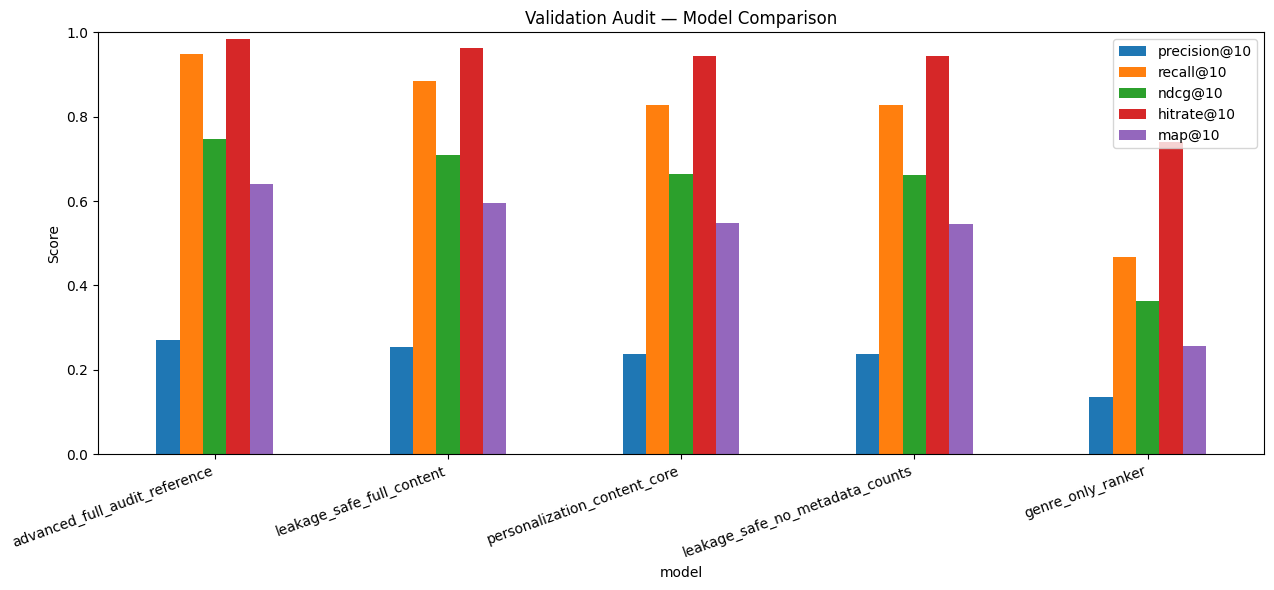

In [22]:
# ============================================================
# 21. LOCK FINAL MODEL USING VALIDATION ONLY
# ============================================================

# IMPORTANT:
# Final model dipilih sekarang, sebelum test matrix/model scores dibuat.

FINAL_MODEL_NAME = str(
    audit_validation.iloc[0]["model"]
)

final_ranker = audit_models[
    FINAL_MODEL_NAME
]

final_feature_indices = AUDIT_VARIANTS[
    FINAL_MODEL_NAME
]["indices"]

final_feature_names = AUDIT_VARIANTS[
    FINAL_MODEL_NAME
]["feature_names"]

final_excluded_features = sorted(
    AUDIT_VARIANTS[
        FINAL_MODEL_NAME
    ]["exclude"]
)

validation_audit_comparison = pd.concat(
    [
        validation_reference,
        audit_validation,
    ],
    ignore_index=True,
).sort_values(
    f"ndcg@{RANKING_K}",
    ascending=False,
)

validation_audit_comparison[
    "selected_final"
] = (
    validation_audit_comparison[
        "model"
    ] == FINAL_MODEL_NAME
)

print(
    "FINAL MODEL LOCKED FROM VALIDATION:",
    FINAL_MODEL_NAME,
)
print(
    "Final feature count:",
    len(final_feature_names),
)
print(
    "Excluded features:",
    final_excluded_features,
)

display(
    validation_audit_comparison
)

plot_cols = [
    f"precision@{RANKING_K}",
    f"recall@{RANKING_K}",
    f"ndcg@{RANKING_K}",
    f"hitrate@{RANKING_K}",
    f"map@{RANKING_K}",
]

ax = (
    validation_audit_comparison
    .set_index("model")[
        plot_cols
    ]
    .plot(
        kind="bar",
        figsize=(13, 6),
    )
)

ax.set_title(
    "Validation Audit — Model Comparison"
)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 22. Final Test

Final model sudah dikunci dari validation.

Sekarang test set baru digunakan untuk pelaporan akhir.

Tabel test tetap menampilkan:
- genre-only baseline,
- advanced full audit reference,
- semua leakage-safe ablation variants.

Tetapi **hasil test tidak mengubah model yang sudah dipilih**.

In [23]:
# ============================================================
# 22. BUILD TEST PROFILE + AFFINITY
# ============================================================

test_profile = build_profile_pack(
    history_stage_max=2,
    label="TEST",
)

test_affinity = compute_metadata_affinities(
    history_stage_max=2,
    profile=test_profile,
    candidates=test_candidates,
    label="TEST",
)

print("Building baseline TEST matrix...")
X_test_base = build_baseline_matrix(
    test_candidates,
    test_profile,
)

print("Building full advanced TEST matrix...")
X_test_adv = build_advanced_matrix(
    test_candidates,
    test_profile,
    test_affinity,
)


Building TEST profile from 27,105,192 historical interactions...

TEST: building weighted history matrix for 20,000 users...
TEST: computing director affinity...
TEST: computing writer affinity...
TEST: computing cast affinity...
TEST: computing keyword affinity...
TEST: computing company affinity...
TEST: computing collection affinity...
Building baseline TEST matrix...
Building full advanced TEST matrix...


In [24]:
# ============================================================
# 23. FINAL TEST EVALUATION
# ============================================================

test_rows = []
test_per_user_by_model = {}
test_scores_by_model = {}

# ---------- Genre-only baseline ----------
baseline_test_scores = (
    baseline_ranker.predict(
        X_test_base
    ).astype(np.float32)
)

baseline_test_metrics, baseline_test_per_user = (
    evaluate_ranking(
        test_candidates,
        baseline_test_scores,
        k=RANKING_K,
    )
)

test_rows.append({
    "model": "genre_only_ranker",
    **baseline_test_metrics,
    "eligible_for_final": False,
    "selected_final": False,
    "reason": "baseline_reference",
})

test_per_user_by_model[
    "genre_only_ranker"
] = baseline_test_per_user

test_scores_by_model[
    "genre_only_ranker"
] = baseline_test_scores

# ---------- Original advanced audit reference ----------
advanced_test_scores = (
    advanced_ranker.predict(
        X_test_adv
    ).astype(np.float32)
)

advanced_test_metrics, advanced_test_per_user = (
    evaluate_ranking(
        test_candidates,
        advanced_test_scores,
        k=RANKING_K,
    )
)

test_rows.append({
    "model": "advanced_full_audit_reference",
    **advanced_test_metrics,
    "eligible_for_final": False,
    "selected_final": False,
    "reason": "contains_stage_based_movie_historical_stats",
})

test_per_user_by_model[
    "advanced_full_audit_reference"
] = advanced_test_per_user

test_scores_by_model[
    "advanced_full_audit_reference"
] = advanced_test_scores

# ---------- Leakage-safe variants ----------
for variant_name, cfg in AUDIT_VARIANTS.items():
    idx = cfg["indices"]

    X_test_variant = X_test_adv[
        :,
        idx,
    ]

    scores = (
        audit_models[
            variant_name
        ]
        .predict(
            X_test_variant
        )
        .astype(np.float32)
    )

    metrics, per_user = evaluate_ranking(
        test_candidates,
        scores,
        k=RANKING_K,
    )

    is_final = (
        variant_name
        == FINAL_MODEL_NAME
    )

    test_rows.append({
        "model": variant_name,
        **metrics,
        "eligible_for_final": True,
        "selected_final": is_final,
        "reason": "leakage_safe_ablation",
    })

    test_per_user_by_model[
        variant_name
    ] = per_user

    test_scores_by_model[
        variant_name
    ] = scores

    del X_test_variant
    gc.collect()

test_audit_comparison = (
    pd.DataFrame(
        test_rows
    )
    .sort_values(
        f"ndcg@{RANKING_K}",
        ascending=False,
    )
    .reset_index(drop=True)
)

final_test_metrics = next(
    row
    for row in test_rows
    if row["model"] == FINAL_MODEL_NAME
)

final_test_per_user = (
    test_per_user_by_model[
        FINAL_MODEL_NAME
    ]
)

final_test_scores = (
    test_scores_by_model[
        FINAL_MODEL_NAME
    ]
)

print("\nFINAL TEST — model selection was already locked:")
display(test_audit_comparison)

print("\nSelected final model test metrics:")
display(
    pd.DataFrame(
        [final_test_metrics]
    )
)


FINAL TEST — model selection was already locked:


,model,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users,eligible_for_final,selected_final,reason
0,advanced_full_audit_reference,0.272925,0.931021,0.730093,0.97895,0.616229,20000,False,False,contains_stage_based_movie_historical_stats
1,leakage_safe_full_content,0.254510,0.865085,0.692434,0.95750,0.575552,20000,True,True,leakage_safe_ablation
2,personalization_content_core,0.237860,0.807737,0.648374,0.93820,0.529522,20000,True,False,leakage_safe_ablation
3,leakage_safe_no_metadata_counts,0.237720,0.808160,0.646937,0.93875,0.527140,20000,True,False,leakage_safe_ablation
4,genre_only_ranker,0.133465,0.445826,0.349845,0.73085,0.244849,20000,False,False,baseline_reference



Selected final model test metrics:


,model,precision@10,recall@10,ndcg@10,hitrate@10,map@10,evaluated_users,eligible_for_final,selected_final,reason
0,leakage_safe_full_content,0.25451,0.865085,0.692434,0.9575,0.575552,20000,True,True,leakage_safe_ablation


In [25]:
# ============================================================
# 24. ABLATION DELTA ANALYSIS
# ============================================================

safe_reference_name = (
    "leakage_safe_full_content"
)

safe_ref_val = (
    audit_validation
    .set_index("model")
    .loc[safe_reference_name]
)

ablation_rows = []

for _, row in audit_validation.iterrows():
    ablation_rows.append({
        "model": row["model"],
        "feature_count": int(
            row["feature_count"]
        ),
        f"validation_ndcg@{RANKING_K}": float(
            row[f"ndcg@{RANKING_K}"]
        ),
        f"delta_ndcg_vs_safe_full@{RANKING_K}": float(
            row[f"ndcg@{RANKING_K}"]
            - safe_ref_val[
                f"ndcg@{RANKING_K}"
            ]
        ),
        f"validation_map@{RANKING_K}": float(
            row[f"map@{RANKING_K}"]
        ),
        "excluded_features": ", ".join(
            sorted(
                AUDIT_VARIANTS[
                    row["model"]
                ]["exclude"]
            )
        ),
    })

ablation_analysis = pd.DataFrame(
    ablation_rows
)

print(
    "Ablation delta terhadap leakage_safe_full_content:"
)
display(ablation_analysis)

# Audit verdict is descriptive, not a claim that one feature is causal.
print(
    "\nInterpretation guide:"
)
print(
    "- Jika no_metadata_counts tetap dekat dengan safe_full, "
    "model tidak bergantung kuat pada jumlah metadata."
)
print(
    "- Jika personalization_content_core tetap unggul atas genre-only, "
    "preference + rich content affinity memberi signal tambahan."
)
print(
    "- Final model tetap dipilih dari validation, bukan dari test."
)

Ablation delta terhadap leakage_safe_full_content:


,model,feature_count,validation_ndcg@10,delta_ndcg_vs_safe_full@10,validation_map@10,excluded_features
0,leakage_safe_full_content,149,0.709252,0.000000,0.596166,"movie_historical_log_count_norm, movie_histori..."
1,personalization_content_core,141,0.663947,-0.045305,0.546918,"movie_has_runtime, movie_has_year, movie_histo..."
2,leakage_safe_no_metadata_counts,145,0.662496,-0.046757,0.544866,"movie_historical_log_count_norm, movie_histori..."



Interpretation guide:
- Jika no_metadata_counts tetap dekat dengan safe_full, model tidak bergantung kuat pada jumlah metadata.
- Jika personalization_content_core tetap unggul atas genre-only, preference + rich content affinity memberi signal tambahan.
- Final model tetap dipilih dari validation, bukan dari test.


In [26]:
# ============================================================
# 25. HISTORY-COHORT EVALUATION
# ============================================================

def cohort_summary(
    per_user_df,
    profile,
    model_name,
):
    df = per_user_df.copy()

    history_count = profile[
        "user_hist_count"
    ][
        df["user_code"].to_numpy(
            dtype=np.int32
        )
    ]

    df["history_count"] = history_count

    df["history_cohort"] = pd.cut(
        df["history_count"],
        bins=[
            -np.inf,
            50,
            150,
            np.inf,
        ],
        labels=[
            "20-50",
            "51-150",
            "151+",
        ],
    )

    metric_cols = [
        f"precision@{RANKING_K}",
        f"recall@{RANKING_K}",
        f"ndcg@{RANKING_K}",
        f"hitrate@{RANKING_K}",
        f"map@{RANKING_K}",
    ]

    summary = (
        df.groupby(
            "history_cohort",
            observed=True,
        )[metric_cols]
        .mean()
        .reset_index()
    )

    summary.insert(
        0,
        "model",
        model_name,
    )

    counts = (
        df.groupby(
            "history_cohort",
            observed=True,
        )
        .size()
        .rename("users")
        .reset_index()
    )

    return summary.merge(
        counts,
        on="history_cohort",
        how="left",
    )

cohort_metrics = pd.concat(
    [
        cohort_summary(
            baseline_test_per_user,
            test_profile,
            "genre_only_ranker",
        ),
        cohort_summary(
            final_test_per_user,
            test_profile,
            FINAL_MODEL_NAME,
        ),
    ],
    ignore_index=True,
)

display(cohort_metrics)

,model,history_cohort,precision@10,recall@10,ndcg@10,hitrate@10,map@10,users
0,genre_only_ranker,20-50,0.152357,0.476915,0.382472,0.779114,0.275021,8484
1,genre_only_ranker,51-150,0.137858,0.448220,0.353514,0.745648,0.244602,6778
2,genre_only_ranker,151+,0.093352,0.386731,0.286174,0.623259,0.191174,4738
3,leakage_safe_full_content,20-50,0.282461,0.902986,0.742564,0.976780,0.639702,8484
4,leakage_safe_full_content,51-150,0.262541,0.866064,0.692738,0.964444,0.569249,6778
5,leakage_safe_full_content,151+,0.192972,0.795818,0.602235,0.913043,0.469700,4738


Feature importance: leakage_safe_full_content


,feature,gain
0,movie_log_n_keywords,556.507507
1,movie_metadata_completeness,75.574280
2,movie_genre_comedy,67.831215
3,user_genre_known_film_noir,67.134476
4,movie_genre_animation,59.878658
5,lang_en,54.974037
6,movie_genre_action,47.901131
7,metadata_affinity_mean,46.123844
8,genre_match_animation,45.943283
9,movie_genre_horror,43.569958


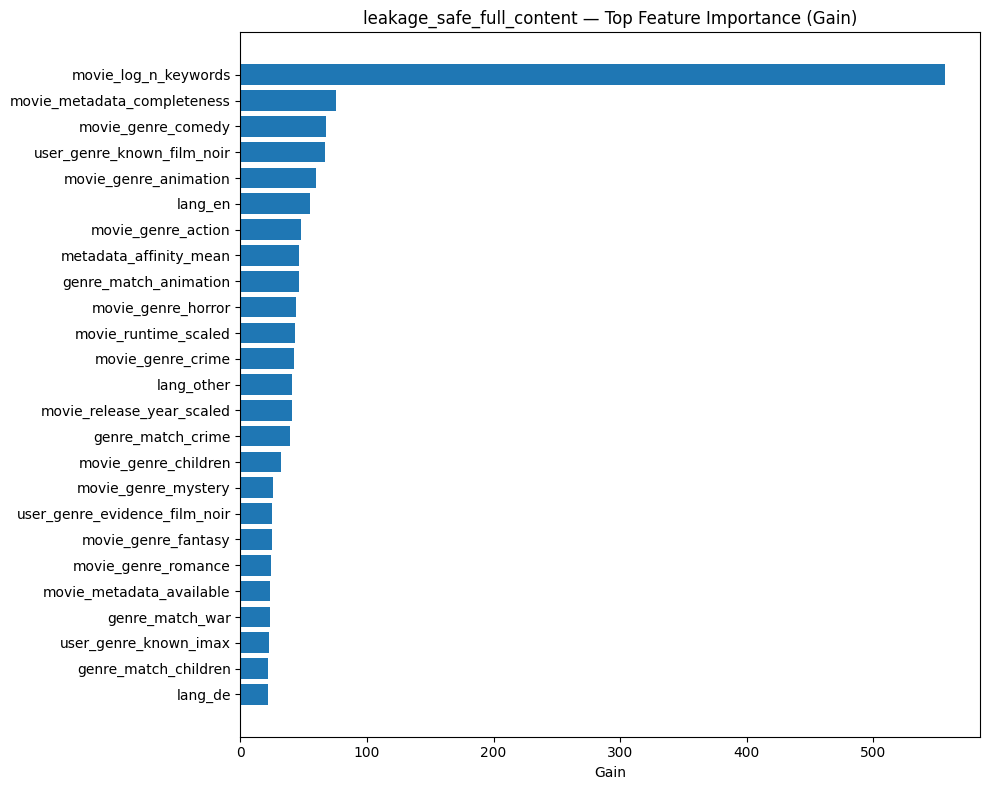

In [27]:
# ============================================================
# 26. FINAL MODEL FEATURE IMPORTANCE
# ============================================================

booster = (
    final_ranker
    .get_booster()
)

raw_importance = booster.get_score(
    importance_type="gain"
)

importance_rows = []

for key, value in raw_importance.items():
    if not key.startswith("f"):
        continue

    try:
        idx = int(key[1:])
    except Exception:
        continue

    feature_name = (
        final_feature_names[idx]
        if idx < len(
            final_feature_names
        )
        else key
    )

    importance_rows.append({
        "feature": feature_name,
        "gain": float(value),
    })

final_feature_importance = (
    pd.DataFrame(
        importance_rows
    )
    .sort_values(
        "gain",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Feature importance:",
    FINAL_MODEL_NAME,
)
display(
    final_feature_importance.head(30)
)

if len(final_feature_importance) > 0:
    top_imp = (
        final_feature_importance
        .head(25)
        .sort_values("gain")
    )

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    ax.barh(
        top_imp["feature"],
        top_imp["gain"],
    )

    ax.set_title(
        f"{FINAL_MODEL_NAME} — Top Feature Importance (Gain)"
    )
    ax.set_xlabel("Gain")
    plt.tight_layout()
    plt.show()

In [28]:
# ============================================================
# 27. TOP-10 DEMO
# ============================================================

qid = test_candidates["qid"]

unique_qids, starts = np.unique(
    qid,
    return_index=True,
)

ends = np.r_[
    starts[1:],
    len(qid),
]

best_demo = None
best_relevant_count = -1

for q, start, end in zip(
    unique_qids,
    starts,
    ends,
):
    ratings_group = test_candidates[
        "raw_rating"
    ][start:end]

    relevant_count = int(
        (
            np.nan_to_num(
                ratings_group,
                nan=-999.0,
            )
            >= RELEVANT_RATING_THRESHOLD
        ).sum()
    )

    if relevant_count > best_relevant_count:
        best_relevant_count = relevant_count
        best_demo = (
            int(q),
            int(start),
            int(end),
        )

demo_qid, demo_start, demo_end = best_demo

demo_scores = final_test_scores[
    demo_start:demo_end
]

demo_order = np.argsort(
    -demo_scores,
    kind="stable",
)[:RANKING_K]

demo_movie_positions = test_candidates[
    "movie_pos"
][
    demo_start:demo_end
][demo_order]

demo_rows = movie_meta.iloc[
    demo_movie_positions
][
    [
        "movieId",
        "title",
        "genres",
        "tmdb_title",
        "release_year_clean",
        "director_names_json",
        "top_cast_names_json",
    ]
].copy()

demo_rows.insert(
    0,
    "rank",
    np.arange(
        1,
        len(demo_rows) + 1,
    ),
)

demo_rows[
    "recommendation_score"
] = demo_scores[
    demo_order
]

demo_rows[
    "actual_rating"
] = test_candidates[
    "raw_rating"
][
    demo_start:demo_end
][demo_order]

demo_rows[
    "graded_relevance"
] = test_candidates[
    "relevance"
][
    demo_start:demo_end
][demo_order]

demo_user_code = int(
    test_candidates[
        "user_code"
    ][demo_start]
)

demo_user_id = int(
    user_ids[
        demo_user_code
    ]
)

print("Demo userId:", demo_user_id)
print(
    "FINAL MODEL:",
    FINAL_MODEL_NAME,
)

display(demo_rows)

Demo userId: 51658
FINAL MODEL: leakage_safe_full_content


,rank,movieId,title,genres,tmdb_title,release_year_clean,director_names_json,top_cast_names_json,recommendation_score,actual_rating,graded_relevance
14478,1,76093,How to Train Your Dragon (2010),Adventure|Animation|Children|Fantasy|IMAX,How to Train Your Dragon,2010.0,"[""Dean DeBlois"", ""Chris Sanders""]","[""Jay Baruchel"", ""Gerard Butler"", ""Craig Fergu...",1.485251,4.0,3
1475,2,1527,"Fifth Element, The (1997)",Action|Adventure|Comedy|Sci-Fi,The Fifth Element,1997.0,"[""Luc Besson""]","[""Bruce Willis"", ""Milla Jovovich"", ""Gary Oldma...",0.725600,4.0,3
579,3,587,Ghost (1990),Comedy|Drama|Fantasy|Romance|Thriller,Ghost,1990.0,"[""Jerry Zucker""]","[""Patrick Swayze"", ""Demi Moore"", ""Whoopi Goldb...",0.532705,4.0,3
6869,4,6993,Hannah and Her Sisters (1986),Comedy|Drama|Romance,Hannah and Her Sisters,1986.0,"[""Woody Allen""]","[""Mia Farrow"", ""Barbara Hershey"", ""Dianne Wies...",0.207701,NaN,0
206,5,208,Waterworld (1995),Action|Adventure|Sci-Fi,Waterworld,1995.0,"[""Kevin Reynolds""]","[""Kevin Costner"", ""Dennis Hopper"", ""Jeanne Tri...",0.120855,4.0,3
12340,6,59421,What Happens in Vegas... (2008),Comedy|Romance,What Happens in Vegas,2008.0,"[""Tom Vaughan""]","[""Cameron Diaz"", ""Ashton Kutcher"", ""Rob Corddr...",0.011097,NaN,0
57927,7,195619,Kim Possible Movie: So the Drama (2005),Action|Adventure|Animation|Children|Drama,Kim Possible Movie: So the Drama,2005.0,"[""Steve Loter""]","[""Christy Carlson Romano"", ""Will Friedle"", ""Na...",-0.126358,NaN,0
1061,8,1088,Dirty Dancing (1987),Drama|Musical|Romance,Dirty Dancing,1987.0,"[""Emile Ardolino""]","[""Jennifer Grey"", ""Patrick Swayze"", ""Jerry Orb...",-0.217478,4.5,4
930,9,951,His Girl Friday (1940),Comedy|Romance,His Girl Friday,1940.0,"[""Howard Hawks""]","[""Cary Grant"", ""Rosalind Russell"", ""Ralph Bell...",-0.276155,NaN,0
71810,10,231883,Forbidden Secrets (2005),Drama|Mystery|Thriller,Forbidden Secrets,2007.0,"[""Richard Roy""]","[""Kristy Swanson"", ""David Keeley"", ""Christophe...",-0.277192,NaN,0


## 28. Hubungan dengan V1

V1 tetap dipertahankan sebagai historical baseline:

- genre-only,
- XGBClassifier,
- LIKE / DISLIKE,
- evaluasi lama pada held-out observed interactions.

V2 final-audit menggunakan protokol yang berbeda:
- per-user chronological split,
- sampled unseen candidates,
- learning-to-rank,
- future-interaction-safe negative sampling,
- leakage-safe feature selection.

Karena protokolnya berbeda, angka seperti `NDCG@10 V1 = 0.825` **tidak boleh dibandingkan langsung** dengan NDCG V2 final.

Perbandingan yang paling adil di notebook ini adalah:

```text
genre_only_ranker
vs
leakage-safe V2 variants
```

karena semuanya memakai split dan candidate construction final-audit yang sama.

In [29]:
# ============================================================
# 29. EXPORT FINAL-AUDIT ARTIFACTS
# ============================================================

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ---------- Save reference models ----------
baseline_model_path = (
    ARTIFACT_DIR
    / "genre_only_xgboost_ranker.json"
)

advanced_reference_path = (
    ARTIFACT_DIR
    / "advanced_full_audit_reference.json"
)

baseline_ranker.save_model(
    baseline_model_path
)

advanced_ranker.save_model(
    advanced_reference_path
)

# ---------- Save all leakage-safe audit models ----------
audit_model_paths = {}

for variant_name, model in audit_models.items():
    path = (
        ARTIFACT_DIR
        / f"{variant_name}.json"
    )

    model.save_model(
        path
    )

    audit_model_paths[
        variant_name
    ] = path

# ---------- Final selected model ----------
final_model_path = (
    ARTIFACT_DIR
    / "final_recommender_xgboost_ranker.json"
)

shutil.copyfile(
    audit_model_paths[
        FINAL_MODEL_NAME
    ],
    final_model_path,
)

# ---------- CSV results ----------
validation_audit_comparison.to_csv(
    ARTIFACT_DIR
    / "validation_audit_comparison.csv",
    index=False,
)

test_audit_comparison.to_csv(
    ARTIFACT_DIR
    / "test_audit_comparison.csv",
    index=False,
)

ablation_analysis.to_csv(
    ARTIFACT_DIR
    / "ablation_validation.csv",
    index=False,
)

cohort_metrics.to_csv(
    ARTIFACT_DIR
    / "history_cohort_metrics.csv",
    index=False,
)

final_feature_importance.to_csv(
    ARTIFACT_DIR
    / "final_feature_importance.csv",
    index=False,
)

demo_rows.to_csv(
    ARTIFACT_DIR
    / "demo_top10.csv",
    index=False,
)

final_test_per_user.to_csv(
    ARTIFACT_DIR
    / "test_per_user_metrics.csv",
    index=False,
)

# ---------- Historical V1 reference ----------
v1_reference = {
    "model": "XGBoost Classifier V1 genre-only",
    "evaluation_note": (
        "Historical reference only. "
        "V1 protocol differs from V2 final-audit."
    ),
    "test": {
        "accuracy": 0.6405,
        "precision": 0.6325,
        "recall": 0.9602,
        "f1": 0.7627,
        "roc_auc": 0.6562,
        "pr_auc": 0.7225,
        "precision@10": 0.8119,
        "recall@10": 0.2561,
        "ndcg@10": 0.8250,
    },
}

with open(
    ARTIFACT_DIR
    / "v1_historical_reference.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        v1_reference,
        f,
        indent=2,
        ensure_ascii=False,
    )

# ---------- Feature config ----------
feature_config = {
    "genres": GENRES,
    "genre_slugs": GENRE_SLUGS,
    "top_languages": TOP_LANGUAGES,
    "language_feature_names": LANGUAGE_FEATURE_NAMES,
    "hash_config": HASH_CONFIG,
    "hash_function": "crc32(salt:entity_id) % dim",
    "baseline_feature_names": BASELINE_FEATURE_NAMES,
    "advanced_all_feature_names": ADVANCED_FEATURE_NAMES,
    "final_feature_names": final_feature_names,
    "final_excluded_features": final_excluded_features,
    "normalization": {
        "rating_min": RATING_MIN,
        "rating_max": RATING_MAX,
        "year_center": YEAR_CENTER,
        "year_scale": YEAR_SCALE,
        "movie_age_max": MOVIE_AGE_MAX,
        "runtime_center": RUNTIME_CENTER,
        "runtime_scale": RUNTIME_SCALE,
        "genre_evidence_log_clip": 200.0,
        "user_history_log_clip": 500.0,
    },
    "fallbacks": {
        "missing_tmdb_metadata": (
            "Use MovieLens genre, zero metadata hash vectors, "
            "and normal content fallbacks."
        ),
        "missing_release_year": YEAR_CENTER,
        "missing_runtime": RUNTIME_CENTER,
        "new_user": (
            "Build preference from onboarding genres + liked movies; "
            "fall back to priors until evidence grows."
        ),
        "new_movie": (
            "Final leakage-safe model does not require historical "
            "MovieLens rating/count features."
        ),
    },
}

with open(
    ARTIFACT_DIR
    / "feature_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        feature_config,
        f,
        indent=2,
        ensure_ascii=False,
    )

# ---------- Preference config ----------
preference_config = {
    "profile_fraction": PROFILE_FRAC,
    "train_end_fraction": TRAIN_END_FRAC,
    "validation_end_fraction": VAL_END_FRAC,
    "minimum_user_ratings": MIN_USER_RATINGS,
    "genre_smoothing_alpha": GENRE_ALPHA,
    "genre_preference": (
        "Smoothed user genre mean rating shrunk to user's own historical mean."
    ),
    "relative_preference": (
        "(smoothed genre mean - user mean) / rating_range"
    ),
    "metadata_affinity": (
        "Cosine similarity between candidate metadata hash vector "
        "and user's centered-rating weighted historical metadata profile."
    ),
    "metadata_history_weight": (
        "(rating - user_historical_mean) / rating_range"
    ),
    "unknown_genre_policy": (
        "Smoothed to user mean; known/evidence features identify no direct evidence."
    ),
}

with open(
    ARTIFACT_DIR
    / "preference_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        preference_config,
        f,
        indent=2,
        ensure_ascii=False,
    )

# ---------- Audit report ----------
audit_report = {
    "audit_version": "V2 final audit",
    "negative_sampling_fix": {
        "before": (
            "Excluded every movie ever rated by the user, including future interactions."
        ),
        "after": (
            "Excludes only movies rated up to the recommendation snapshot."
        ),
        "status": "fixed",
    },
    "temporal_risk_features": sorted(
        TEMPORAL_RISK_FEATURES
    ),
    "temporal_risk_policy": (
        "Stage-based global movie historical rating/count features are "
        "retained only for audit reference and are not eligible for final selection."
    ),
    "audit_variants": {
        name: {
            "description": cfg["description"],
            "feature_count": len(
                cfg["feature_names"]
            ),
            "excluded_features": sorted(
                cfg["exclude"]
            ),
        }
        for name, cfg in AUDIT_VARIANTS.items()
    },
    "selection_rule": (
        f"Highest validation NDCG@{RANKING_K} among leakage-safe variants only."
    ),
    "selected_final_model": FINAL_MODEL_NAME,
    "test_did_not_select_model": True,
}

with open(
    ARTIFACT_DIR
    / "audit_report.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        audit_report,
        f,
        indent=2,
        ensure_ascii=False,
    )

# ---------- Model config ----------
model_config = {
    "project": (
        "Aoranema Personalized Movie Recommendation V2 Final Audit"
    ),
    "dataset": [
        "MovieLens 32M",
        "Aoranema TMDB Metadata",
    ],
    "run_mode": RUN_MODE,
    "selected_model": FINAL_MODEL_NAME,
    "selection_metric": (
        f"validation_ndcg@{RANKING_K}"
    ),
    "selection_scope": (
        "leakage_safe_variants_only"
    ),
    "ranking_k": RANKING_K,
    "relevance_mapping": {
        "rating>=4.5": 4,
        "rating>=4.0": 3,
        "rating>=3.5": 2,
        "rating>=3.0": 1,
        "rating<3.0": 0,
        "sampled_unseen": 0,
    },
    "binary_relevant_threshold": (
        RELEVANT_RATING_THRESHOLD
    ),
    "candidate_sampling": {
        "train_max_observed_per_user": (
            MAX_TRAIN_OBSERVED_PER_USER
        ),
        "train_negatives_per_user": (
            TRAIN_NEGATIVES_PER_USER
        ),
        "eval_max_observed_per_user": (
            MAX_EVAL_OBSERVED_PER_USER
        ),
        "eval_negatives_per_user": (
            EVAL_NEGATIVES_PER_USER
        ),
        "max_train_users": max_train_users,
        "max_eval_users": max_eval_users,
        "future_interaction_policy": (
            "Future-rated movies are NOT excluded from the unseen negative pool."
        ),
        "release_filter": (
            "Known movie release year must be <= recommendation snapshot year."
        ),
    },
    "xgboost": {
        "objective": "rank:ndcg",
        "eval_metric": f"ndcg@{RANKING_K}",
        "n_estimators": XGB_N_ESTIMATORS,
        "learning_rate": XGB_LEARNING_RATE,
        "max_depth": XGB_MAX_DEPTH,
        "max_bin": XGB_MAX_BIN,
        "early_stopping_rounds": (
            XGB_EARLY_STOPPING
        ),
    },
    "validation_metrics": (
        validation_audit_comparison
        .to_dict(
            orient="records"
        )
    ),
    "test_metrics": (
        test_audit_comparison
        .to_dict(
            orient="records"
        )
    ),
}

with open(
    ARTIFACT_DIR
    / "model_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        model_config,
        f,
        indent=2,
        ensure_ascii=False,
    )

# ---------- Data quality ----------
data_quality.update({
    "ratings_loaded": int(
        N_RATINGS
    ),
    "users_loaded": int(
        N_USERS
    ),
    "eligible_users": int(
        (
            user_counts
            >= MIN_USER_RATINGS
        ).sum()
    ),
    "train_candidate_users": int(
        len(
            train_candidates[
                "group_user_codes"
            ]
        )
    ),
    "validation_candidate_users": int(
        len(
            val_candidates[
                "group_user_codes"
            ]
        )
    ),
    "test_candidate_users": int(
        len(
            test_candidates[
                "group_user_codes"
            ]
        )
    ),
})

with open(
    ARTIFACT_DIR
    / "data_quality.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        data_quality,
        f,
        indent=2,
        ensure_ascii=False,
    )

# ---------- Final metrics ----------
metrics_final = {
    "selected_model": FINAL_MODEL_NAME,
    "selection_rule": (
        "Validation only; test not used for model selection."
    ),
    "validation": (
        validation_audit_comparison
        .to_dict(
            orient="records"
        )
    ),
    "test": (
        test_audit_comparison
        .to_dict(
            orient="records"
        )
    ),
    "ablation": (
        ablation_analysis
        .to_dict(
            orient="records"
        )
    ),
    "cohort_metrics": (
        cohort_metrics
        .to_dict(
            orient="records"
        )
    ),
}

with open(
    ARTIFACT_DIR
    / "metrics_v2_final_audit.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        metrics_final,
        f,
        indent=2,
        ensure_ascii=False,
    )

# ---------- ZIP ----------
zip_path = shutil.make_archive(
    "/kaggle/working/aoranema_recommender_v2_final_audit",
    "zip",
    ARTIFACT_DIR,
)

print(
    "FINAL MODEL:",
    FINAL_MODEL_NAME,
)
print(
    "Final model file:",
    final_model_path,
)
print(
    "ZIP:",
    zip_path,
)

print("\nArtifacts:")
for p in sorted(
    ARTIFACT_DIR.iterdir()
):
    print(
        "-",
        p.name,
        f"({p.stat().st_size / 1024 / 1024:.2f} MB)"
    )

FINAL MODEL: leakage_safe_full_content
Final model file: /kaggle/working/aoranema_recommender_v2_final_audit/final_recommender_xgboost_ranker.json
ZIP: /kaggle/working/aoranema_recommender_v2_final_audit.zip

Artifacts:
- ablation_validation.csv (0.00 MB)
- advanced_full_audit_reference.json (0.47 MB)
- audit_report.json (0.00 MB)
- data_quality.json (0.00 MB)
- demo_top10.csv (0.00 MB)
- feature_config.json (0.01 MB)
- final_feature_importance.csv (0.01 MB)
- final_recommender_xgboost_ranker.json (8.12 MB)
- genre_only_xgboost_ranker.json (6.86 MB)
- history_cohort_metrics.csv (0.00 MB)
- leakage_safe_full_content.json (8.12 MB)
- leakage_safe_no_metadata_counts.json (8.09 MB)
- metrics_v2_final_audit.json (0.01 MB)
- model_config.json (0.01 MB)
- personalization_content_core.json (8.15 MB)
- preference_config.json (0.00 MB)
- test_audit_comparison.csv (0.00 MB)
- test_per_user_metrics.csv (1.23 MB)
- v1_historical_reference.json (0.00 MB)
- validation_audit_comparison.csv (0.00 MB)


# 30. Setelah Final Audit Selesai

Output utama:

```text
aoranema_recommender_v2_final_audit/
├── final_recommender_xgboost_ranker.json   ⭐ model production candidate
├── model_config.json
├── feature_config.json
├── preference_config.json
├── audit_report.json
├── metrics_v2_final_audit.json
│
├── validation_audit_comparison.csv
├── test_audit_comparison.csv
├── ablation_validation.csv
├── history_cohort_metrics.csv
├── final_feature_importance.csv
├── test_per_user_metrics.csv
├── demo_top10.csv
│
├── genre_only_xgboost_ranker.json
├── advanced_full_audit_reference.json
└── leakage-safe variant model files
```

Dan ZIP:

```text
/kaggle/working/aoranema_recommender_v2_final_audit.zip
```

## Kapan recommendation experiment dianggap selesai?

Jika:

1. notebook selesai tanpa error,
2. final model berasal dari salah satu leakage-safe variant,
3. final model tetap mengungguli genre-only baseline pada validation dan test,
4. ablation tidak menunjukkan bahwa performa sepenuhnya bergantung pada metadata-count proxy,
5. output artifacts tersimpan,

maka recommendation experiment dapat **di-freeze**.

Setelah itu jangan membuat V3 lagi kecuali ada masalah baru yang nyata.

Tahap berikutnya adalah production:

```text
recommendation/src/
├── preference_builder.py
├── preference_updater.py
├── feature_builder.py
├── predictor.py
└── ranker.py

api/
└── recommendation endpoints

Laravel
↓
candidate film bioskop
↓
ML ranker
↓
Top-10 recommendation
```